# ASSIGNMENT CDS

# Problem Statement

Study analysis on the public sentiment towards a company and its stock effect their prices by extracting opinions from Twitter in determining whether public opinion has impact on the stock prices of the company.

In [1]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")

True
NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import sys
from collections import Counter

# Load dataset
df = pd.read_csv("dataset.csv")

print(f"Dataset loaded successfully!")
print(f"Total rows: {len(df):,}")
print(f"Total columns: {df.shape[1]}")
df.head()

Dataset loaded successfully!
Total rows: 143,282
Total columns: 15


C:\Users\hafiz\AppData\Local\Temp\ipykernel_26440\1689644038.py:10: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dataset.csv")


,Unnamed: 0,TWEET,STOCK,DATE,LAST_PRICE,1_DAY_RETURN,2_DAY_RETURN,3_DAY_RETURN,7_DAY_RETURN,PX_VOLUME,VOLATILITY_10D,VOLATILITY_30D,LSTM_POLARITY,TEXTBLOB_POLARITY,MENTION
0,0,RT @robertoglezcano: @amazon #Patents Show Fl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Amazon,31/01/2017,823.48,0.008379,0.014924,0.014924,-0.001263,3.137196e+06,13.447,16.992,1.000,0.0,@amazon,NaN
2,1,@FAME95FM1 Jamaicans make money with @Payoneer...,PayPal,31/01/2017,39.780000,0.002011,0.012318,0.012318,5.480141e-02,9100057.000,18.769,16.099,-1,0.0,@PayPal
3,2,@CBSi Jamaicans make money with @Payoneer @Pay...,PayPal,31/01/2017,39.780000,0.002011,0.012318,0.012318,5.480141e-02,9100057.000,18.769,16.099,1,0.0,@PayPal
4,3,@Hitz92fm Jamaicans make money with @Payoneer ...,PayPal,31/01/2017,39.780000,0.002011,0.012318,0.012318,5.480141e-02,9100057.000,18.769,16.099,-1,0.0,@PayPal


# Exploratory Data Analysis (EDA)
- Column names
- Missing values
- Duplicate rows
- Data types
- Date range
- Number of tweets per company/stock
- Number of tweets per date

## General Dataset Overview

In [3]:
# --- 1. Column names and data types ---
print("=" * 50)
print("COLUMN NAMES AND DATA TYPES")
print("=" * 50)
print(df.dtypes)
print()

COLUMN NAMES AND DATA TYPES
Unnamed: 0            object
TWEET                 object
STOCK                 object
DATE                  object
LAST_PRICE           float64
1_DAY_RETURN         float64
2_DAY_RETURN         float64
3_DAY_RETURN         float64
7_DAY_RETURN         float64
PX_VOLUME            float64
VOLATILITY_10D       float64
VOLATILITY_30D       float64
LSTM_POLARITY         object
TEXTBLOB_POLARITY     object
MENTION               object
dtype: object



In [4]:
# --- 2. Shape of the dataset (rows, columns) ---
print("=" * 50)
print("DATASET SHAPE")
print("=" * 50)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print()

DATASET SHAPE
Rows    : 143,282
Columns : 15



In [5]:
# --- 3. Missing values per column ---
print("=" * 50)
print("MISSING VALUES PER COLUMN")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum():,}")

MISSING VALUES PER COLUMN
                   Missing Count  Missing %
Unnamed: 0                 18521      12.93
TWEET                          3       0.00
STOCK                      58106      40.55
DATE                       58106      40.55
LAST_PRICE                 58106      40.55
1_DAY_RETURN               58106      40.55
2_DAY_RETURN               58106      40.55
3_DAY_RETURN               58106      40.55
7_DAY_RETURN               58106      40.55
PX_VOLUME                  58106      40.55
VOLATILITY_10D             58111      40.56
VOLATILITY_30D             58117      40.56
LSTM_POLARITY              58107      40.55
TEXTBLOB_POLARITY          97688      68.18
MENTION                   116209      81.11

Total missing values: 871,604


In [6]:
# --- 4. Duplicate rows ---
print("=" * 50)
print("DUPLICATE ROWS")
print("=" * 50)
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count:,}")
if duplicate_count > 0:
    print("Removing duplicates...")
    df = df.drop_duplicates()
    print(f"Rows after removing duplicates: {len(df):,}")

DUPLICATE ROWS
Number of duplicate rows: 34,531
Removing duplicates...
Rows after removing duplicates: 108,751


In [7]:
# --- 5. Basic descriptive statistics for numerical columns ---
print("=" * 50)
print("DESCRIPTIVE STATISTICS (NUMERICAL COLUMNS)")
print("=" * 50)
df.describe()

DESCRIPTIVE STATISTICS (NUMERICAL COLUMNS)


,LAST_PRICE,1_DAY_RETURN,2_DAY_RETURN,3_DAY_RETURN,7_DAY_RETURN,PX_VOLUME,VOLATILITY_10D,VOLATILITY_30D
count,50646.000000,50646.000000,50646.000000,5.064600e+04,5.064600e+04,5.064600e+04,50642.000000,50635.000000
mean,385.366638,0.002566,0.004550,3.670428e+06,1.694464e+06,6.885840e+06,16.096976,12.006351
std,4178.673334,0.020762,0.029304,9.783974e+06,6.442278e+06,1.270438e+07,15.530235,13.629565
min,-0.173554,-0.177851,-0.204959,-1.778512e-01,-2.049587e-01,1.000000e+00,-1.000000,-1.000000
25%,0.000000,-0.006198,-0.010287,-4.420177e-03,8.535458e-04,1.963225e+01,1.000000,0.118182
50%,31.830000,0.000000,0.001084,1.296811e-02,5.831221e-02,1.022243e+06,15.837000,12.486000
75%,101.910000,0.009826,0.015833,2.480604e+06,2.789275e+01,8.105294e+06,22.583000,19.239000
max,165500.000000,0.243639,0.267113,3.081068e+08,1.439475e+08,1.698037e+08,124.137000,74.355000


## Stock Exploratory Data Analysis

In [8]:
# --- Number of tweets per company/stock ---
print("=" * 50)
print("NUMBER OF TWEETS PER STOCK/COMPANY")
print("=" * 50)
stock_counts = df['STOCK'].value_counts()
print(stock_counts)
print(f"\nTotal unique stocks/companies: {df['STOCK'].nunique()}")

NUMBER OF TWEETS PER STOCK/COMPANY
STOCK
Nike       3797
Reuters    2482
Apple      2238
eBay       2063
Netflix    1942
           ... 
114.48        1
75.64         1
368.49        1
112.05        1
175.9         1
Name: count, Length: 2696, dtype: int64

Total unique stocks/companies: 2696


C:\Users\hafiz\AppData\Local\Temp\ipykernel_26440\355015616.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stock_counts.index, y=stock_counts.values, palette='Blues_r')


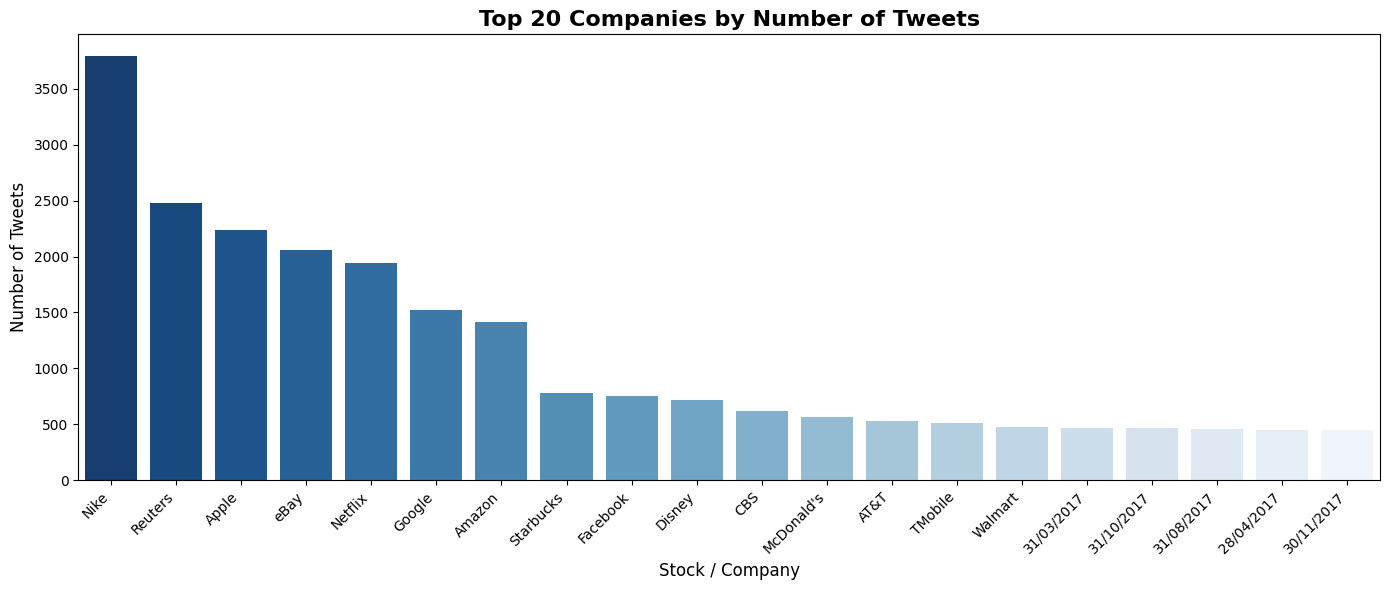

Most tweeted company: Nike with 3,797 tweets


In [9]:
# --- Bar chart: Tweets per stock ---
plt.figure(figsize=(14, 6))
stock_counts = df['STOCK'].value_counts().head(20)
sns.barplot(x=stock_counts.index, y=stock_counts.values, palette='Blues_r')
plt.title('Top 20 Companies by Number of Tweets', fontsize=16, fontweight='bold')
plt.xlabel('Stock / Company', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(f"Most tweeted company: {stock_counts.index[0]} with {stock_counts.values[0]:,} tweets")

In [10]:
# --- Date range analysis ---
date_column = None
for col in df.columns:
    if 'date' in col.lower() or 'time' in col.lower() or 'created' in col.lower():
        date_column = col
        break

if date_column:
    df[date_column] = pd.to_datetime(df[date_column], errors='coerce')
    
    # Drop NaT values before calculating range
    valid_dates = df[date_column].dropna()
    
    print("=" * 50)
    print(f"DATE RANGE ANALYSIS (column: '{date_column}')")
    print("=" * 50)
    
    if len(valid_dates) > 0:
        earliest = valid_dates.min()
        latest   = valid_dates.max()
        
        print(f"Earliest tweet : {earliest}")
        print(f"Latest tweet   : {latest}")
        
        # Fix: convert to Python native datetime before subtracting
        # This avoids the pandas OutOfBoundsDatetime overflow error
        try:
            delta = latest.to_pydatetime() - earliest.to_pydatetime()
            print(f"Date range     : {delta.days} days")
        except Exception:
            print(f"Date range     : Unable to calculate (dates may be out of bounds)")
        
        print(f"Valid date rows : {len(valid_dates):,} out of {len(df):,}")
    else:
        print("No valid dates found after parsing.")
else:
    print("No date column found in dataset.")

DATE RANGE ANALYSIS (column: 'DATE')
Earliest tweet : 1703-05-01 00:00:00
Latest tweet   : 2248-05-01 00:00:00
Date range     : 199058 days
Valid date rows : 27,187 out of 108,751


C:\Users\hafiz\AppData\Local\Temp\ipykernel_26440\2407055537.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[date_column] = pd.to_datetime(df[date_column], errors='coerce')


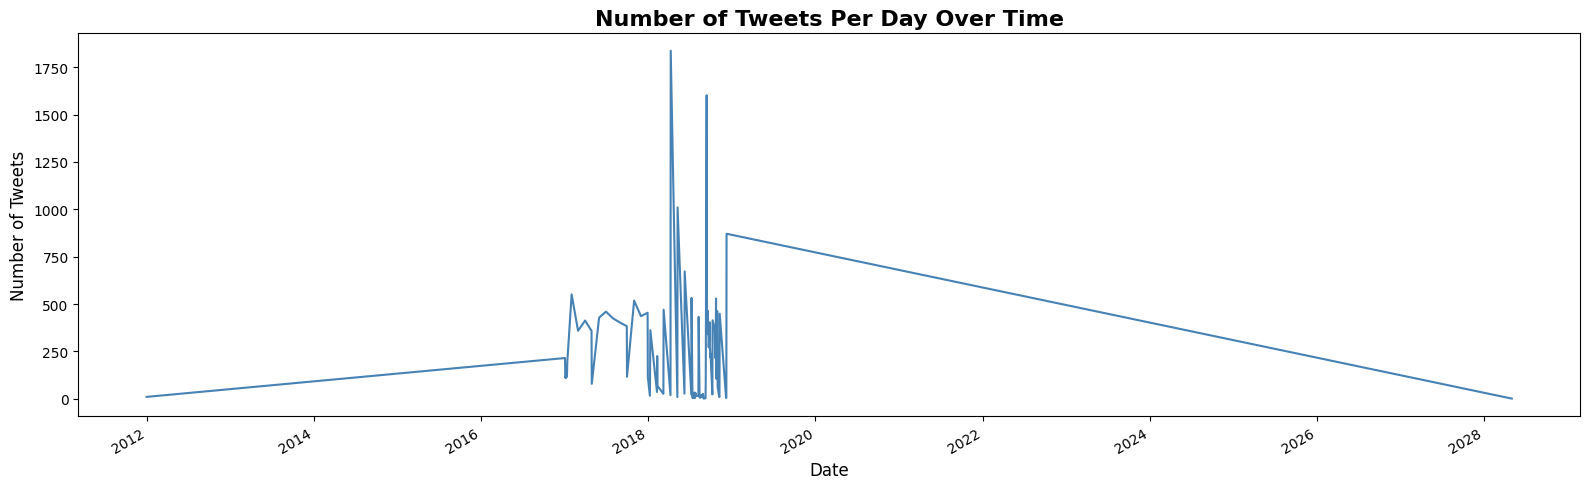

Average tweets per day: 224
Peak tweets in a day  : 1,837 on 2018-04-09 00:00:00


In [11]:
# --- 1. Clean and filter the dates first ---
df[date_column] = pd.to_datetime(df[date_column], errors='coerce')

# Keep only reasonable dates for Twitter (2006 to near future)
df = df[
    (df[date_column].dt.year >= 2006) &
    (df[date_column].dt.year <= 2030)
]

# --- Number of tweets per date (if date column exists) ---
if date_column and df[date_column].notna().sum() > 0:
    df['date_only'] = df[date_column].dt.floor('D')
    tweets_per_date = df.groupby('date_only').size()

    plt.figure(figsize=(16, 5))
    tweets_per_date.plot(kind='line', color='steelblue', linewidth=1.5)
    plt.title('Number of Tweets Per Day Over Time', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Number of Tweets', fontsize=12)
    plt.tight_layout()
    plt.show()

    print(f"Average tweets per day: {tweets_per_date.mean():.0f}")
    print(f"Peak tweets in a day  : {tweets_per_date.max():,} on {tweets_per_date.idxmax()}")
else:
    print("Skipping date trend chart — no valid date column found.")

## Text Exploratory Data Analysis

In [12]:
# --- Drop rows with missing tweet text ---
print(f"Rows before dropping missing tweets: {len(df):,}")
df = df.dropna(subset=['TWEET'])
print(f"Rows after dropping missing tweets : {len(df):,}")

Rows before dropping missing tweets: 27,084
Rows after dropping missing tweets : 27,084


In [13]:
# --- Tweet length distribution ---
df['tweet_length'] = df['TWEET'].astype(str).apply(len)
df['word_count']   = df['TWEET'].astype(str).apply(lambda x: len(x.split()))

print("=" * 50)
print("TWEET LENGTH STATISTICS")
print("=" * 50)
print(f"Average tweet length (chars) : {df['tweet_length'].mean():.1f}")
print(f"Average tweet word count     : {df['word_count'].mean():.1f}")
print(f"Shortest tweet               : {df['tweet_length'].min()} characters")
print(f"Longest tweet                : {df['tweet_length'].max()} characters")

TWEET LENGTH STATISTICS
Average tweet length (chars) : 130.8
Average tweet word count     : 18.5
Shortest tweet               : 6 characters
Longest tweet                : 266 characters


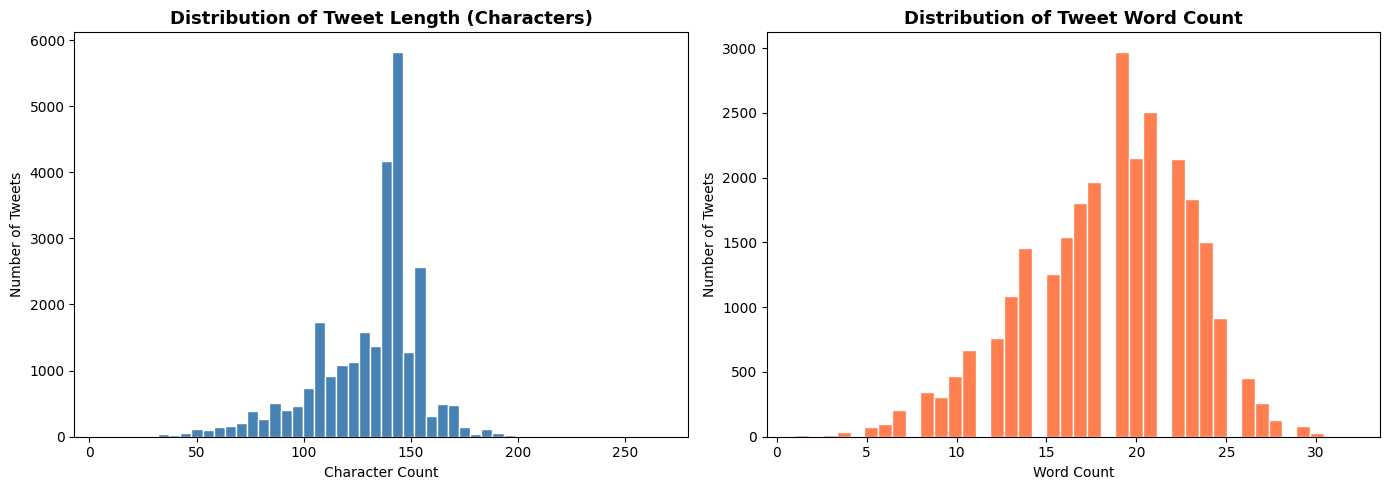

In [14]:
# --- Tweet length histogram ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['tweet_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Tweet Length (Characters)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Number of Tweets')

axes[1].hist(df['word_count'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Tweet Word Count', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Number of Tweets')

plt.tight_layout()
plt.show()

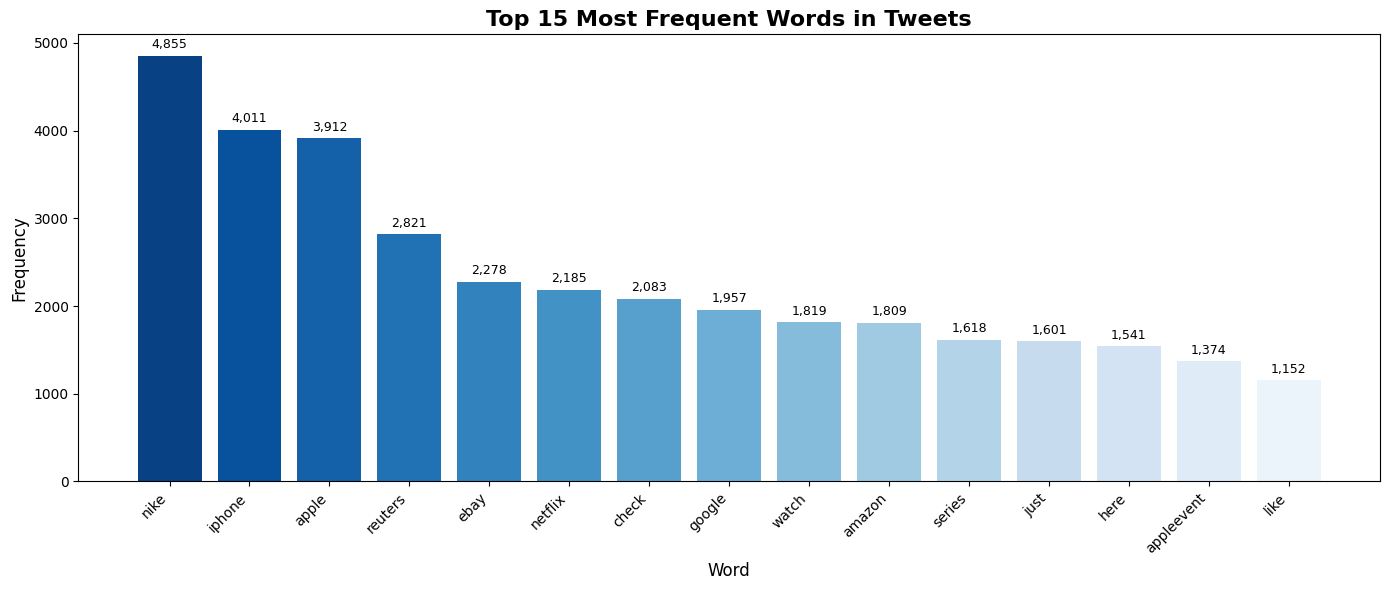

In [15]:
# --- Top 15 most frequent words (basic word frequency) ---
all_tweets_text = ' '.join(df['TWEET'].astype(str)).lower()
words = re.findall(r'\b[a-z]{4,}\b', all_tweets_text)

# Remove common noise words that are not meaningful
noise_words = ['http', 'https', 'that', 'this', 'with', 'from', 'have', 'will',
               'your', 'they', 'been', 'were', 'said', 'what', 'when', 'their']
meaningful_words = [w for w in words if w not in noise_words]

word_counts = Counter(meaningful_words)
top_15 = word_counts.most_common(15)
top_words = [w[0] for w in top_15]
top_counts = [w[1] for w in top_15]

plt.figure(figsize=(14, 6))
bars = plt.bar(top_words, top_counts, color=sns.color_palette('Blues_r', 15))
plt.title('Top 15 Most Frequent Words in Tweets', fontsize=16, fontweight='bold')
plt.xlabel('Word', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
for bar, count in zip(bars, top_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{count:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

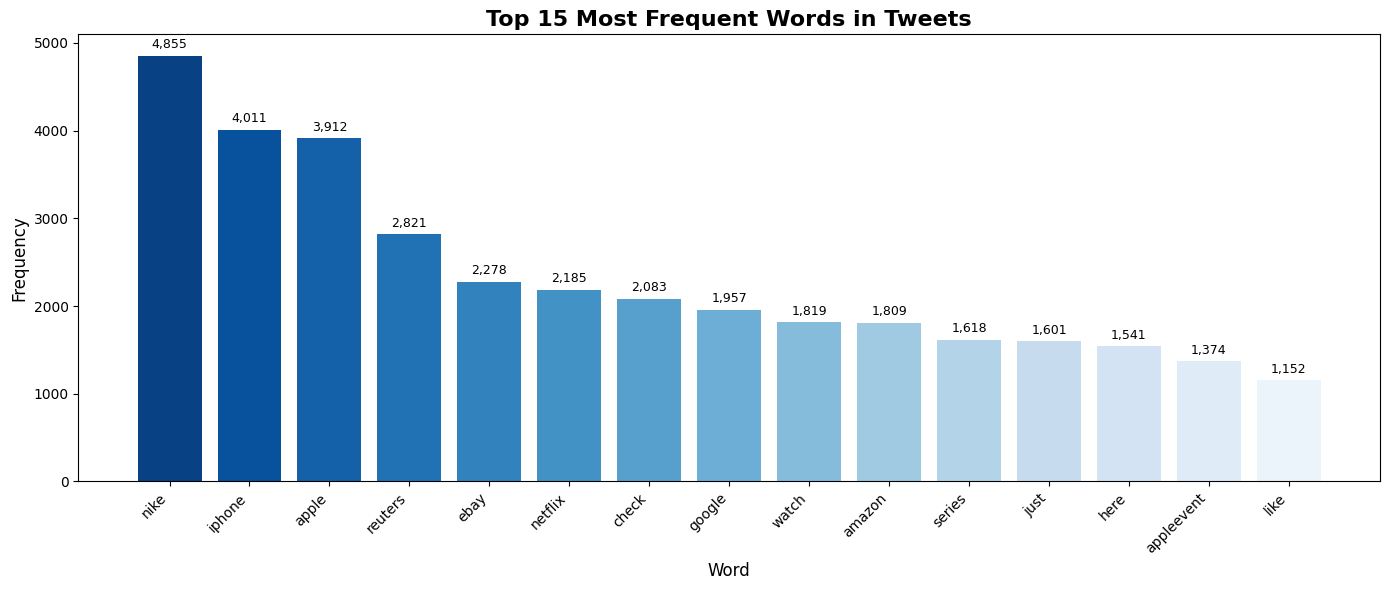

In [16]:
# --- Top 15 most frequent words (basic word frequency) ---
all_tweets_text = ' '.join(df['TWEET'].astype(str)).lower()
words = re.findall(r'\b[a-z]{4,}\b', all_tweets_text)

# Remove common noise words that are not meaningful
noise_words = ['http', 'https', 'that', 'this', 'with', 'from', 'have', 'will',
               'your', 'they', 'been', 'were', 'said', 'what', 'when', 'their']
meaningful_words = [w for w in words if w not in noise_words]

word_counts = Counter(meaningful_words)
top_15 = word_counts.most_common(15)
top_words = [w[0] for w in top_15]
top_counts = [w[1] for w in top_15]

plt.figure(figsize=(14, 6))
bars = plt.bar(top_words, top_counts, color=sns.color_palette('Blues_r', 15))
plt.title('Top 15 Most Frequent Words in Tweets', fontsize=16, fontweight='bold')
plt.xlabel('Word', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
for bar, count in zip(bars, top_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{count:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Preprocessing


### Intsall Libraries & Download NLTK Resources

In [17]:
# Install required libraries
!{sys.executable} -m pip install nltk wordcloud afinn scikit-learn seaborn textblob --quiet

import nltk

# Download all required NLTK resources
nltk.download('punkt')                      # Tokenization rules
nltk.download('punkt_tab')                  # Updated tokenization
nltk.download('stopwords')                  # Stopword list
nltk.download('wordnet')                    # Dictionary for lemmatization
nltk.download('omw-1.4')                    # Supporting data for wordnet
nltk.download('averaged_perceptron_tagger_eng')  # POS tagging
nltk.download('maxent_ne_chunker_tab')      # NER chunker
nltk.download('words')                      # Required for NER
nltk.download('vader_lexicon')              # VADER sentiment

print("\nAll resources downloaded successfully!")


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...



All resources downloaded successfully!


[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## Data Cleaning

In [18]:
import re

def clean_noise(text):
    """
    Removes URLs, @mentions, hashtags, special characters, and extra whitespace.
    Also applies case folding (lowercase).
    """
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)   # Remove URLs
    text = re.sub(r'@\w+', '', text)                         # Remove @mentions
    text = re.sub(r'#\w+', '', text)                         # Remove #hashtags
    text = re.sub(r'[^a-zA-Z\s]', '', text)                  # Remove special chars & numbers
    text = text.lower()                                        # Case folding
    text = re.sub(r'\s+', ' ', text).strip()                 # Remove extra whitespace
    return text

# Apply to TWEET column and save in new column
df['clean_text'] = df['TWEET'].apply(clean_noise)

# Preview result
print("Before cleaning:")
print(df['TWEET'].iloc[0])
print("\nAfter cleaning:")
print(df['clean_text'].iloc[0])

Before cleaning:
@FAME95FM1 Jamaicans make money with @Payoneer @PayPal, @paxuminc, @ecoPayz and @okpaycom https://t.co/FWzqUrgsqs

After cleaning:
jamaicans make money with and


## Sentence Segmentation

In [19]:
from nltk.tokenize import sent_tokenize

# Apply sentence segmentation on the ORIGINAL tweet (before cleaning)
# We use raw text here because we want to preserve sentence boundaries
df['sentences'] = df['TWEET'].apply(sent_tokenize)

# Show example
print("Original tweet:")
print(df['TWEET'].iloc[0])
print("\nSentences:")
for i, s in enumerate(df['sentences'].iloc[0]):
    print(f"  Sentence {i+1}: {s}")

Original tweet:
@FAME95FM1 Jamaicans make money with @Payoneer @PayPal, @paxuminc, @ecoPayz and @okpaycom https://t.co/FWzqUrgsqs

Sentences:
  Sentence 1: @FAME95FM1 Jamaicans make money with @Payoneer @PayPal, @paxuminc, @ecoPayz and @okpaycom https://t.co/FWzqUrgsqs


## Tokenization

In [20]:
from nltk.tokenize import word_tokenize

def tokenize_text(text):
    """
    Tokenizes text into words and removes punctuation.
    isalpha() keeps only words with letters (no numbers, no symbols).
    """
    tokens = word_tokenize(str(text))
    # Remove punctuation — keep only alphabetical tokens
    tokens = [word for word in tokens if word.isalpha()]
    return tokens

df['tokens'] = df['clean_text'].apply(tokenize_text)

# Preview
print("Cleaned text:")
print(df['clean_text'].iloc[0])
print("\nTokens:")
print(df['tokens'].iloc[0])

Cleaned text:
jamaicans make money with and

Tokens:
['jamaicans', 'make', 'money', 'with', 'and']


## Handling Abbreviations

In [21]:
# Abbreviation dictionary — tailored for stock market / financial tweets
abbreviation_dict = {
    'rt'  : 'retweet',
    'roi' : 'return on investment',
    'ipo' : 'initial public offering',
    'etf' : 'exchange traded fund',
    'vix' : 'volatility index',
    'pe'  : 'price earnings',
    'eps' : 'earnings per share',
    'ytd' : 'year to date',
    'q'   : 'quarter',
    'u'   : 'you',
    'ur'  : 'your',
    'dm'  : 'direct message',
    'omg' : 'oh my god',
    'lol' : 'laugh out loud',
    'imo' : 'in my opinion',
    'ngl' : 'not going to lie',
    'tbh' : 'to be honest',
    'asap': 'as soon as possible',
    'fyi' : 'for your information',
}

def expand_abbreviations(token_list):
    """
    Replaces abbreviations in the token list with their full forms.
    Returns a flat list of tokens after expansion.
    """
    expanded = []
    for word in token_list:
        expanded_word = abbreviation_dict.get(word.lower(), word)
        expanded.extend(expanded_word.split())
    return expanded

df['expanded_tokens'] = df['tokens'].apply(expand_abbreviations)

# Preview
print("Tokens before abbreviation expansion:")
print(df['tokens'].iloc[0])
print("\nTokens after abbreviation expansion:")
print(df['expanded_tokens'].iloc[0])

Tokens before abbreviation expansion:
['jamaicans', 'make', 'money', 'with', 'and']

Tokens after abbreviation expansion:
['jamaicans', 'make', 'money', 'with', 'and']


## Stopword Removal

In [22]:
from nltk.corpus import stopwords

# Load NLTK English stopwords
stop_words = set(stopwords.words('english'))

# Add custom stopwords relevant to the stock tweet dataset
custom_stopwords = [
    'next', 'via', 'amp', 'rt', 'co',
    'stock', 'market', 'share', 'price',   # too generic for this dataset
    'today', 'year', 'time', 'make', 'said'
]
stop_words.update(custom_stopwords)

def remove_stopwords(token_list):
    """
    Removes stopwords from the token list.
    Only keeps words that are NOT in the stopword set.
    """
    return [word for word in token_list if word not in stop_words]

df['filtered_tokens'] = df['expanded_tokens'].apply(remove_stopwords)

# Preview — compare before and after
print(f"Tokens before stopword removal ({len(df['expanded_tokens'].iloc[0])} words):")
print(df['expanded_tokens'].iloc[0])
print(f"\nTokens after stopword removal ({len(df['filtered_tokens'].iloc[0])} words):")
print(df['filtered_tokens'].iloc[0])

Tokens before stopword removal (5 words):
['jamaicans', 'make', 'money', 'with', 'and']

Tokens after stopword removal (2 words):
['jamaicans', 'money']


## Stemming & Lemmatization

In [23]:
from nltk.stem import PorterStemmer, WordNetLemmatizer

stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def apply_stemming(token_list):
    """Applies Porter Stemmer — chops word endings using rules."""
    return [stemmer.stem(word) for word in token_list]

def apply_lemmatization(token_list):
    """Applies WordNet Lemmatizer — looks up dictionary root form."""
    return [lemmatizer.lemmatize(word) for word in token_list]

df['stemmed_words']    = df['filtered_tokens'].apply(apply_stemming)
df['lemmatized_words'] = df['filtered_tokens'].apply(apply_lemmatization)

print("Stemming and Lemmatization complete!")
print("\nExample comparison:")
print(f"Filtered tokens  : {df['filtered_tokens'].iloc[0]}")
print(f"Stemmed          : {df['stemmed_words'].iloc[0]}")
print(f"Lemmatized       : {df['lemmatized_words'].iloc[0]}")

Stemming and Lemmatization complete!

Example comparison:
Filtered tokens  : ['jamaicans', 'money']
Stemmed          : ['jamaican', 'money']
Lemmatized       : ['jamaican', 'money']


In [24]:
# --- Full pipeline comparison for one tweet ---
row = 5   # Change this to inspect different tweets

print("FULL PREPROCESSING PIPELINE COMPARISON")
print("=" * 60)
print(f"1. ORIGINAL TWEET:\n   {df['TWEET'].iloc[row]}")
print(f"\n2. CLEANED (noise removed, lowercased):\n   {df['clean_text'].iloc[row]}")
print(f"\n3. TOKENIZED (words split, punctuation removed):\n   {df['tokens'].iloc[row]}")
print(f"\n4. ABBREVIATIONS EXPANDED:\n   {df['expanded_tokens'].iloc[row]}")
print(f"\n5. STOPWORDS REMOVED:\n   {df['filtered_tokens'].iloc[row]}")
print(f"\n6a. STEMMED (chopped endings):\n   {df['stemmed_words'].iloc[row]}")
print(f"\n6b. LEMMATIZED (dictionary root — USE THIS):\n   {df['lemmatized_words'].iloc[row]}")

FULL PREPROCESSING PIPELINE COMPARISON
1. ORIGINAL TWEET:
   RT @cultcommoncore: Dumping @Starbucks
Is like dropping cable tv.
You wonder how you paid 
SO much
For such crap
For SO long.… 

2. CLEANED (noise removed, lowercased):
   rt dumping is like dropping cable tv you wonder how you paid so much for such crap for so long

3. TOKENIZED (words split, punctuation removed):
   ['rt', 'dumping', 'is', 'like', 'dropping', 'cable', 'tv', 'you', 'wonder', 'how', 'you', 'paid', 'so', 'much', 'for', 'such', 'crap', 'for', 'so', 'long']

4. ABBREVIATIONS EXPANDED:
   ['retweet', 'dumping', 'is', 'like', 'dropping', 'cable', 'tv', 'you', 'wonder', 'how', 'you', 'paid', 'so', 'much', 'for', 'such', 'crap', 'for', 'so', 'long']

5. STOPWORDS REMOVED:
   ['retweet', 'dumping', 'like', 'dropping', 'cable', 'tv', 'wonder', 'paid', 'much', 'crap', 'long']

6a. STEMMED (chopped endings):
   ['retweet', 'dump', 'like', 'drop', 'cabl', 'tv', 'wonder', 'paid', 'much', 'crap', 'long']

6b. LEMMATIZED (d

## Pos Tagging

In [25]:
import nltk

def apply_pos_tagging(token_list):
    """Applies POS tagging to a list of tokens."""
    return nltk.pos_tag(token_list)

# Apply POS tagging to lemmatized words
df['pos_tags'] = df['lemmatized_words'].apply(apply_pos_tagging)

# Preview
print("Lemmatized tokens:")
print(df['lemmatized_words'].iloc[0])
print("\nPOS Tags:")
print(df['pos_tags'].iloc[0])
print("\nPOS Tag reference: NN=Noun, VB=Verb, JJ=Adjective, RB=Adverb, NNP=Proper Noun")

Lemmatized tokens:
['jamaican', 'money']

POS Tags:
[('jamaican', 'JJ'), ('money', 'NN')]

POS Tag reference: NN=Noun, VB=Verb, JJ=Adjective, RB=Adverb, NNP=Proper Noun


C:\Users\hafiz\AppData\Local\Temp\ipykernel_26440\3357157534.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tag_labels, y=tag_values, palette='coolwarm')


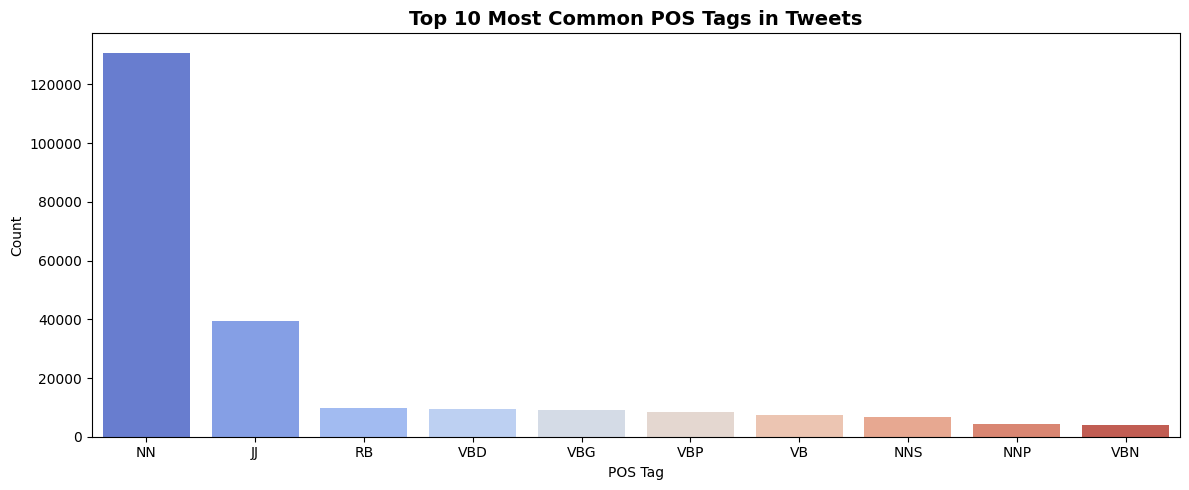

In [26]:
# --- Most common POS tags in the dataset ---
all_tags = []
for tag_list in df['pos_tags']:
    all_tags.extend([tag for _, tag in tag_list])

tag_counts = Counter(all_tags).most_common(10)
tag_labels = [t[0] for t in tag_counts]
tag_values = [t[1] for t in tag_counts]

plt.figure(figsize=(12, 5))
sns.barplot(x=tag_labels, y=tag_values, palette='coolwarm')
plt.title('Top 10 Most Common POS Tags in Tweets', fontsize=14, fontweight='bold')
plt.xlabel('POS Tag')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Chunking

In [27]:
# Define a grammar rule to extract Noun Phrases (NP)
# Rule: optional determiner + any adjectives + a noun
grammar = "NP: {<DT>?<JJ>*<NN.*>+}"
chunk_parser = nltk.RegexpParser(grammar)

def extract_noun_phrases(pos_tagged_tokens):
    """Extracts noun phrases from POS-tagged tokens using chunking."""
    tree = chunk_parser.parse(pos_tagged_tokens)
    noun_phrases = []
    for subtree in tree.subtrees():
        if subtree.label() == 'NP':
            phrase = ' '.join(word for word, tag in subtree.leaves())
            noun_phrases.append(phrase)
    return noun_phrases

df['noun_phrases'] = df['pos_tags'].apply(extract_noun_phrases)

# Preview
print("POS Tags:")
print(df['pos_tags'].iloc[0])
print("\nExtracted Noun Phrases:")
print(df['noun_phrases'].iloc[0])

POS Tags:
[('jamaican', 'JJ'), ('money', 'NN')]

Extracted Noun Phrases:
['jamaican money']


C:\Users\hafiz\AppData\Local\Temp\ipykernel_26440\2270355375.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=np_values, y=np_words, palette='viridis')


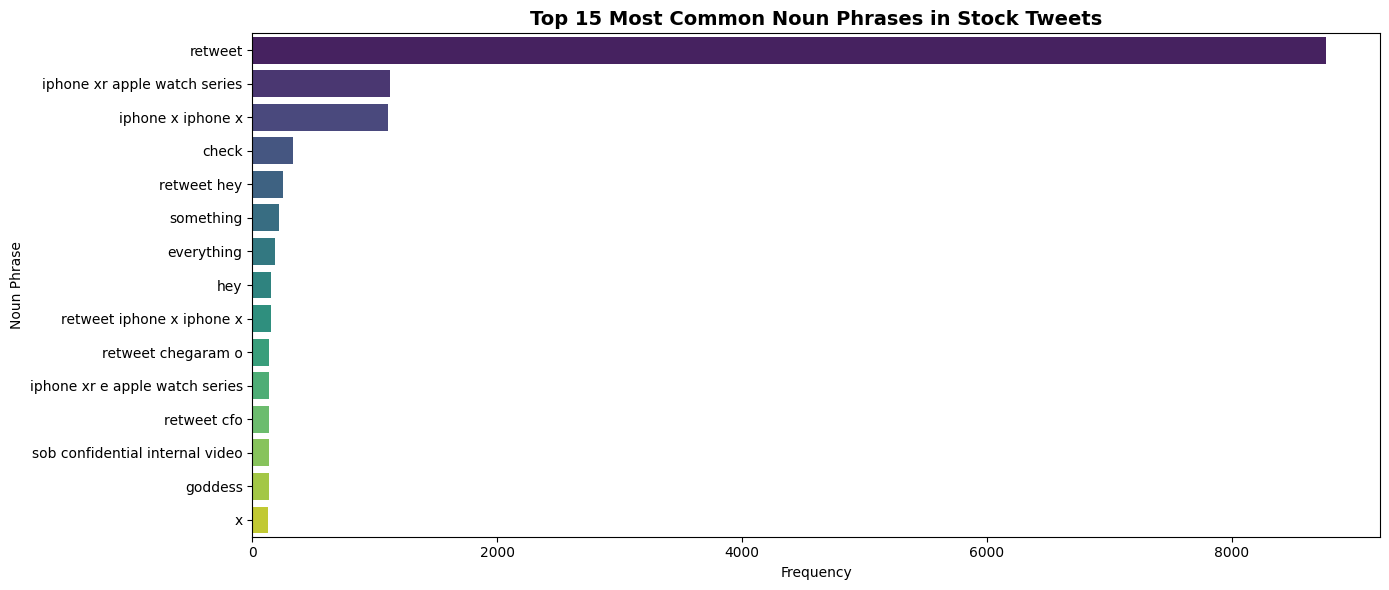

In [28]:
# --- Top 15 most common noun phrases across all tweets ---
all_noun_phrases = []
for phrase_list in df['noun_phrases']:
    all_noun_phrases.extend(phrase_list)

np_counts = Counter(all_noun_phrases).most_common(15)
np_words  = [n[0] for n in np_counts]
np_values = [n[1] for n in np_counts]

plt.figure(figsize=(14, 6))
sns.barplot(x=np_values, y=np_words, palette='viridis')
plt.title('Top 15 Most Common Noun Phrases in Stock Tweets', fontsize=14, fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Noun Phrase')
plt.tight_layout()
plt.show()

## Named Entity Recognition

In [29]:
def apply_ner(raw_text):
    """
    Applies Named Entity Recognition to RAW text (not cleaned).
    NER needs original capitalisation to identify proper nouns.
    Returns a list of (entity_text, entity_type) tuples.
    """
    tokens  = nltk.word_tokenize(str(raw_text))
    pos_tag = nltk.pos_tag(tokens)
    tree    = nltk.ne_chunk(pos_tag)
    
    entities = []
    for chunk in tree:
        if hasattr(chunk, 'label'):
            entity_text = ' '.join(c[0] for c in chunk)
            entity_type = chunk.label()
            entities.append((entity_text, entity_type))
    return entities

# Apply to a sample (NER is slow — run on first 500 rows for demonstration)
print("Applying NER to sample of 500 tweets")
df_sample_ner = df.head(500).copy()
df_sample_ner['ner_entities'] = df_sample_ner['TWEET'].apply(apply_ner)

# Store back into main df for the sample rows
df.loc[df_sample_ner.index, 'ner_entities'] = df_sample_ner['ner_entities']

print("NER complete!")
print("\nExample:")
print(f"Tweet   : {df['TWEET'].iloc[0]}")
print(f"Entities: {df_sample_ner['ner_entities'].iloc[0]}")

Applying NER to sample of 500 tweets
NER complete!

Example:
Tweet   : @FAME95FM1 Jamaicans make money with @Payoneer @PayPal, @paxuminc, @ecoPayz and @okpaycom https://t.co/FWzqUrgsqs
Entities: [('FAME95FM1 Jamaicans', 'ORGANIZATION')]


TOP 15 MOST FREQUENT ENTITIES
Entity
Starbucks           82
Starbucks CEO       35
Trump               18
Welcome             15
BoycottStarbucks    14
Share               12
Competition         11
ASOS                11
Simply              11
Weds                11
Disney              11
U.S.                10
Reuters              9
GM                   8
ABC                  8
Name: count, dtype: int64

ENTITY TYPE DISTRIBUTION
Type
PERSON          417
ORGANIZATION    389
GPE              94
FACILITY          6
LOCATION          1
GSP               1
Name: count, dtype: int64


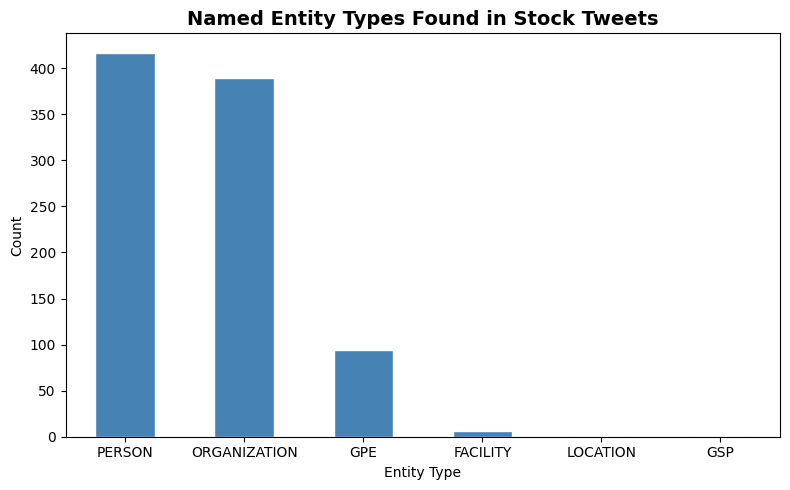

In [30]:
# --- Most frequently identified entities and their types ---
all_entities = []
for ent_list in df_sample_ner['ner_entities']:
    all_entities.extend(ent_list)

if all_entities:
    entity_df = pd.DataFrame(all_entities, columns=['Entity', 'Type'])
    
    print("=" * 50)
    print("TOP 15 MOST FREQUENT ENTITIES")
    print("=" * 50)
    print(entity_df['Entity'].value_counts().head(15))
    
    print("\n" + "=" * 50)
    print("ENTITY TYPE DISTRIBUTION")
    print("=" * 50)
    print(entity_df['Type'].value_counts())
    
    # Plot entity type distribution
    plt.figure(figsize=(8, 5))
    entity_df['Type'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
    plt.title('Named Entity Types Found in Stock Tweets', fontsize=14, fontweight='bold')
    plt.xlabel('Entity Type')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No entities found in the sample.")

## Word Cloud Visualisation

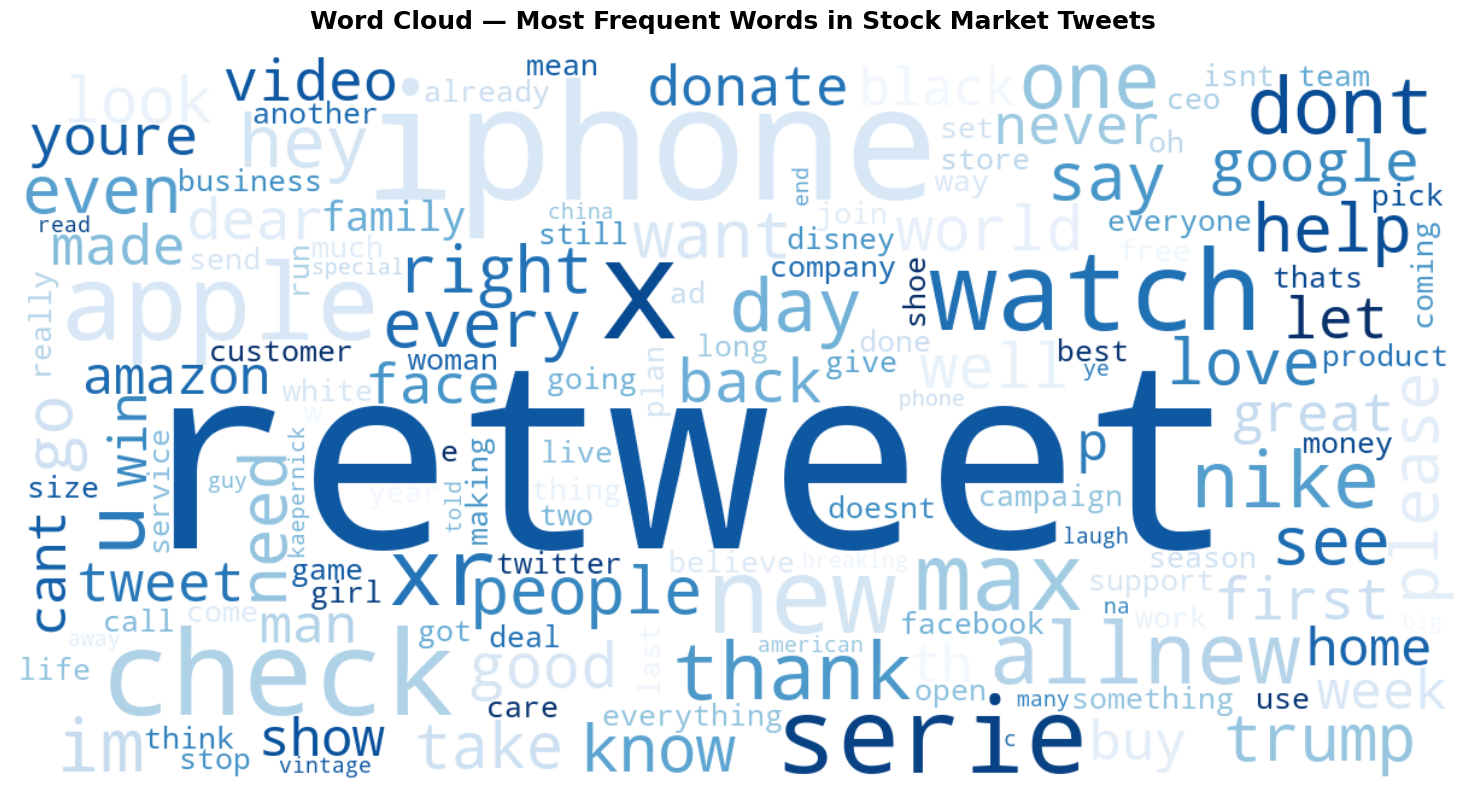

Word cloud generated from 243,894 cleaned tokens.


In [31]:
from wordcloud import WordCloud

# Join all lemmatized words into one big string
all_clean_words = []
for word_list in df['lemmatized_words']:
    all_clean_words.extend(word_list)

text_for_cloud = ' '.join(all_clean_words)

# Generate the word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='Blues',
    max_words=150,
    collocations=False   # Avoid repeating word pairs
).generate(text_for_cloud)

# Plot
plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Most Frequent Words in Stock Market Tweets',
          fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
print(f"Word cloud generated from {len(all_clean_words):,} cleaned tokens.")

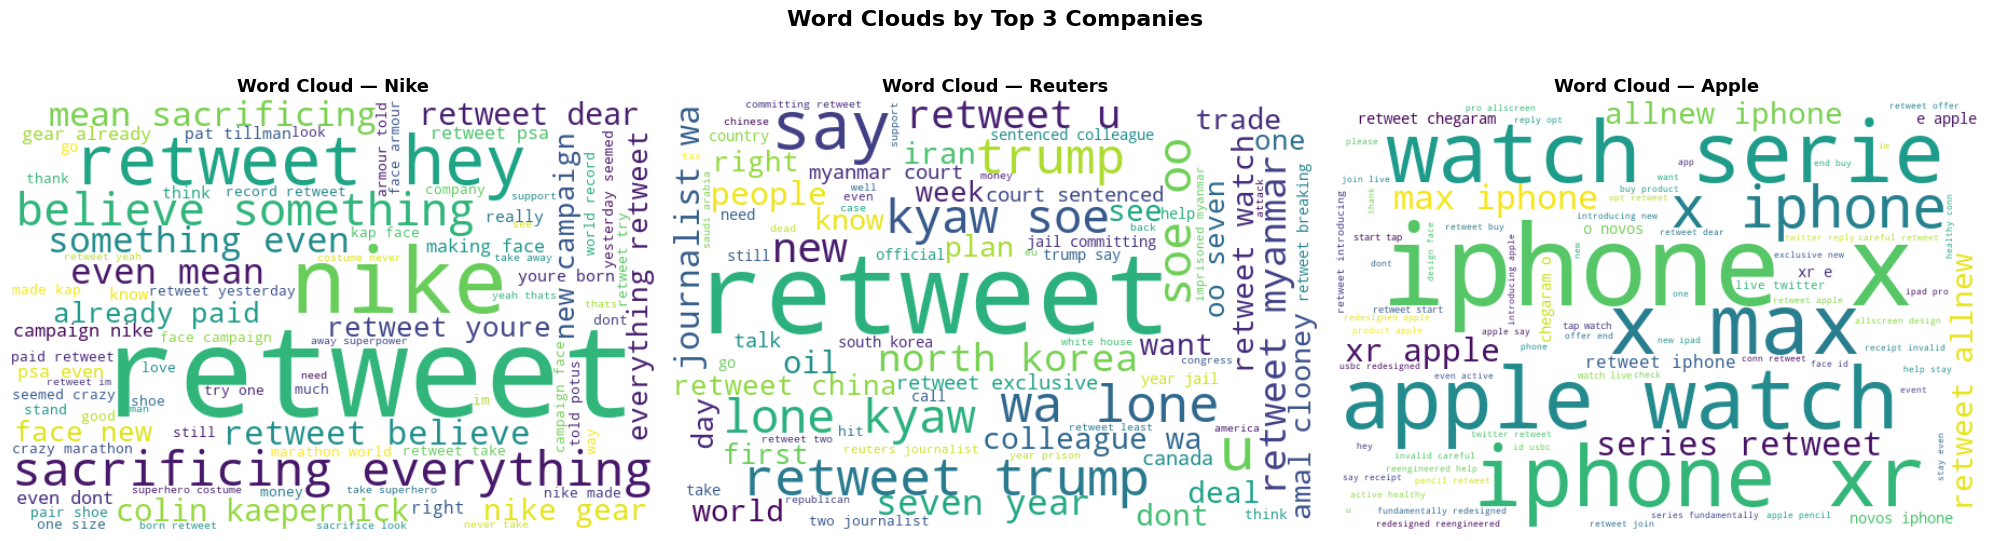

In [32]:
# --- Word cloud per company (top 3 stocks) ---
top_3_stocks = df['STOCK'].value_counts().head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, stock in zip(axes, top_3_stocks):
    stock_words = []
    for word_list in df[df['STOCK'] == stock]['lemmatized_words']:
        stock_words.extend(word_list)
    
    if stock_words:
        wc = WordCloud(width=600, height=400, background_color='white',
                       colormap='viridis', max_words=80).generate(' '.join(stock_words))
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'Word Cloud — {stock}', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Word Clouds by Top 3 Companies', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Feature Engineering

- TF-IDF Features
- Word Embedding Features
- BERT Embeddings

### TF-IDF

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Join lemmatized tokens back into a string for TF-IDF
# TF-IDF requires a string input, not a list
df['joined_tokens'] = df['lemmatized_words'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else ''
)

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,        # Keep top 1000 words only
    stop_words='english',     # Additional stopword removal
    ngram_range=(1, 2),       # Include single words AND 2-word phrases
)

# Fit and transform — learns vocabulary AND converts to numbers
tfidf_matrix = tfidf_vectorizer.fit_transform(df['joined_tokens'])

# Convert to readable DataFrame
feature_names = tfidf_vectorizer.get_feature_names_out()
df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names,
    index=df.index
)

print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")
print(f"(Rows = tweets, Columns = unique words/phrases)")
print(f"\nThis is called a SPARSE MATRIX because most values are 0.0")
print(f"Non-zero values: {tfidf_matrix.nnz:,} out of {tfidf_matrix.shape[0] * tfidf_matrix.shape[1]:,} total")
print(f"Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.1f}% zeros")
df_tfidf.head()

TF-IDF Matrix Shape: (27084, 1000)
(Rows = tweets, Columns = unique words/phrases)

This is called a SPARSE MATRIX because most values are 0.0
Non-zero values: 151,908 out of 27,084,000 total
Sparsity: 99.4% zeros


,absolutely,access,account,action,active,active healthy,actress,actress appearing,actual,actually,...,year,yes,yesterday,yesterday crazy,yo,youll,young,youre,youre born,youve
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


C:\Users\hafiz\AppData\Local\Temp\ipykernel_26440\3311479054.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_tfidf.values, y=mean_tfidf.index, palette='Blues_r')


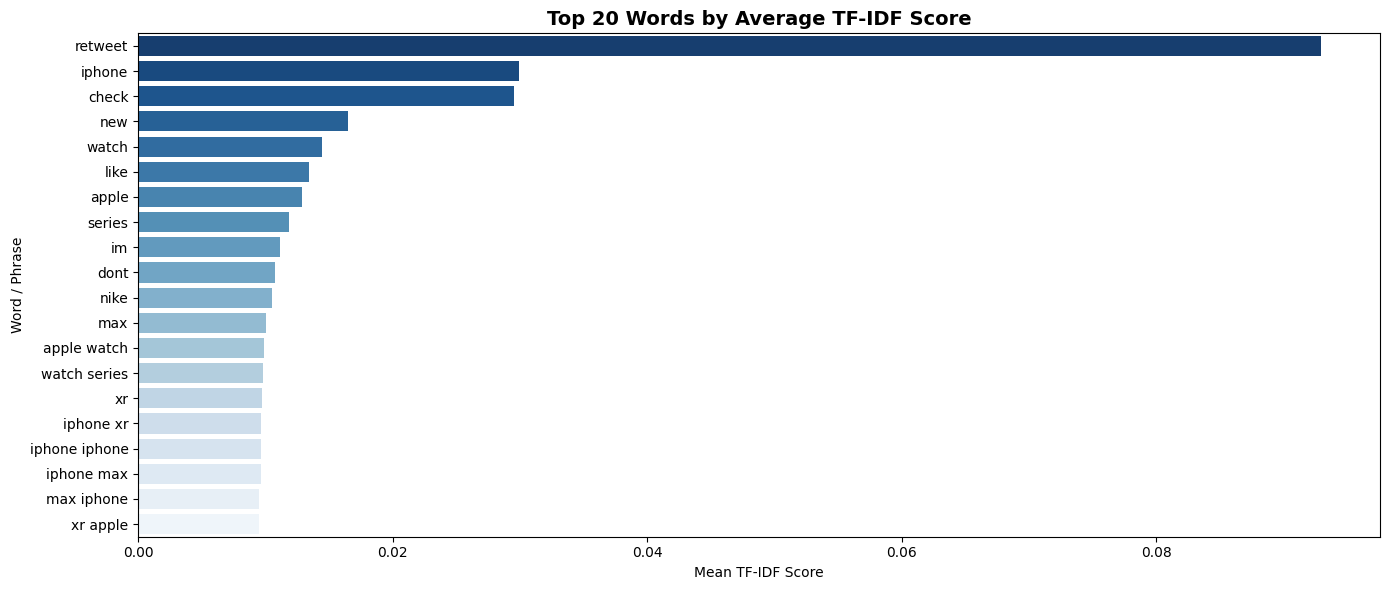

Higher score = more unique and important to specific tweets


In [34]:
# --- Top TF-IDF terms overall ---
mean_tfidf = df_tfidf.mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(14, 6))
sns.barplot(x=mean_tfidf.values, y=mean_tfidf.index, palette='Blues_r')
plt.title('Top 20 Words by Average TF-IDF Score', fontsize=14, fontweight='bold')
plt.xlabel('Mean TF-IDF Score')
plt.ylabel('Word / Phrase')
plt.tight_layout()
plt.show()
print("Higher score = more unique and important to specific tweets")

In [35]:
# --- TF-IDF top terms per stock company ---
top_stocks_tfidf = df['STOCK'].value_counts().head(3).index.tolist()

print("=" * 60)
print("TOP 10 TF-IDF TERMS PER COMPANY")
print("=" * 60)

for stock in top_stocks_tfidf:
    stock_indices = df.index[df['STOCK'] == stock]
    if len(stock_indices) > 0:
        stock_tfidf_mean = df_tfidf.loc[stock_indices].mean().sort_values(ascending=False).head(10)
        print(f"\n{stock}:")
        for term, score in stock_tfidf_mean.items():
            print(f"  {term:<25} {score:.4f}")

TOP 10 TF-IDF TERMS PER COMPANY

Nike:
  retweet                   0.0849
  nike                      0.0725
  like                      0.0270
  shoe                      0.0244
  dont                      0.0237
  believe                   0.0216
  kaepernick                0.0194
  face                      0.0187
  mean                      0.0185
  sacrificing               0.0185

Reuters:
  retweet                   0.1151
  trump                     0.0530
  say                       0.0428
  china                     0.0230
  retweet trump             0.0228
  journalist                0.0196
  reuters                   0.0195
  myanmar                   0.0167
  korea                     0.0163
  north                     0.0162

Apple:
  iphone                    0.3530
  apple                     0.1471
  watch                     0.1189
  apple watch               0.1189
  watch series              0.1179
  xr                        0.1175
  iphone xr                 0.117

### Word Embeddeding Features

In [36]:
try:
    from gensim.models import Word2Vec
    GENSIM_AVAILABLE = True
except ImportError:
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'gensim', '--quiet'])
    from gensim.models import Word2Vec
    GENSIM_AVAILABLE = True

import numpy as np

# Prepare sentences — list of token lists
sentences = df['lemmatized_words'].tolist()
sentences = [s for s in sentences if isinstance(s, list) and len(s) > 0]

# Train Word2Vec model on our tweet corpus
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,    # 100-dimensional word vectors
    window=5,           # Context window size
    min_count=2,        # Ignore words appearing less than 2 times
    workers=4,          # Parallel threads
    epochs=10
)

print(f"Word2Vec model trained!")
print(f"Vocabulary size: {len(w2v_model.wv):,} words")
print(f"Vector dimensions: {w2v_model.vector_size}")

# Example: most similar words
try:
    print(f"\nWords most similar to 'stock':")
    for word, score in w2v_model.wv.most_similar('stock', topn=5):
        print(f"  {word:<20} similarity: {score:.3f}")
except KeyError:
    print("\n'stock' not in vocabulary — try another word")

Word2Vec model trained!
Vocabulary size: 11,165 words
Vector dimensions: 100

Words most similar to 'stock':
  spin                 similarity: 0.969
  university           similarity: 0.968
  eu                   similarity: 0.968
  opec                 similarity: 0.967
  threat               similarity: 0.966


In [37]:
import numpy as np

def get_tweet_embedding(token_list, model, vector_size=100):
    """
    Converts a list of tokens into a single vector by averaging
    the word vectors of all known words in the tweet.
    """
    vectors = []
    for word in token_list:
        if word in model.wv:
            vectors.append(model.wv[word])
    
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(vector_size)  # Return zero vector if no known words

# Generate embeddings for all tweets
embeddings = df['lemmatized_words'].apply(
    lambda x: get_tweet_embedding(x if isinstance(x, list) else [], w2v_model)
)

# Convert to DataFrame
embedding_cols = [f'w2v_{i}' for i in range(w2v_model.vector_size)]
df_embeddings = pd.DataFrame(embeddings.tolist(), columns=embedding_cols, index=df.index)

print(f"Word2Vec embeddings shape: {df_embeddings.shape}")
print(f"Each tweet is now represented as a {w2v_model.vector_size}-dimensional vector")
df_embeddings.head(3)

Word2Vec embeddings shape: (27084, 100)
Each tweet is now represented as a 100-dimensional vector


,w2v_0,w2v_1,w2v_2,w2v_3,w2v_4,w2v_5,w2v_6,w2v_7,w2v_8,w2v_9,...,w2v_90,w2v_91,w2v_92,w2v_93,w2v_94,w2v_95,w2v_96,w2v_97,w2v_98,w2v_99
2,-0.057517,0.205419,0.243166,-0.425035,-0.294739,-0.66806,0.356404,-0.091103,0.032192,-0.434931,...,0.295544,-0.07658,-0.093385,0.105934,-0.390982,-0.133372,0.225808,-0.585202,-0.006239,0.135001
3,-0.057517,0.205419,0.243166,-0.425035,-0.294739,-0.66806,0.356404,-0.091103,0.032192,-0.434931,...,0.295544,-0.07658,-0.093385,0.105934,-0.390982,-0.133372,0.225808,-0.585202,-0.006239,0.135001
4,-0.057517,0.205419,0.243166,-0.425035,-0.294739,-0.66806,0.356404,-0.091103,0.032192,-0.434931,...,0.295544,-0.07658,-0.093385,0.105934,-0.390982,-0.133372,0.225808,-0.585202,-0.006239,0.135001


### BERT Embeddings

In [38]:
try:
    from sentence_transformers import SentenceTransformer
    SBERT_AVAILABLE = True
except ImportError:
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'sentence-transformers', '--quiet'])
    from sentence_transformers import SentenceTransformer
    SBERT_AVAILABLE = True

# Load a lightweight pre-trained BERT model
print("Loading BERT model (this may take a moment on first run)...")
bert_model = SentenceTransformer('all-MiniLM-L6-v2')  # Small but effective model
print("BERT model loaded!")

# Apply to a sample of tweets (BERT is slow on large datasets)
sample_size = min(500, len(df))
df_bert_sample = df.head(sample_size).copy()

print(f"\nGenerating BERT embeddings for {sample_size} tweets...")
bert_embeddings = bert_model.encode(
    df_bert_sample['TWEET'].astype(str).tolist(),
    show_progress_bar=True,
    batch_size=32
)

print(f"\nBERT Embeddings shape: {bert_embeddings.shape}")
print(f"Each tweet is represented as a {bert_embeddings.shape[1]}-dimensional BERT vector")

c:\Users\hafiz\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading BERT model (this may take a moment on first run)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5294.80it/s]


BERT model loaded!

Generating BERT embeddings for 500 tweets...


Batches: 100%|██████████| 16/16 [00:00<00:00, 17.64it/s]


BERT Embeddings shape: (500, 384)
Each tweet is represented as a 384-dimensional BERT vector


In [39]:
# --- Compare TF-IDF vs Word2Vec vs BERT ---
print("=" * 60)
print("FEATURE COMPARISON SUMMARY")
print("=" * 60)

comparison_data = {
    'Feature Type'   : ['TF-IDF', 'Word2Vec', 'BERT'],
    'Dimensions'     : [1000, 100, 384],
    'Type'           : ['Sparse (mostly zeros)', 'Dense (all values)', 'Dense (contextual)'],
    'Context Aware'  : ['No', 'Partial', 'Yes — fully contextual'],
    'Training'       : ['No training needed', 'Trained on our data', 'Pre-trained on massive corpus'],
    'Best For'       : ['Traditional ML models', 'Custom embeddings', 'Deep learning / transformers'],
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

FEATURE COMPARISON SUMMARY
Feature Type  Dimensions                  Type          Context Aware                      Training                     Best For
      TF-IDF        1000 Sparse (mostly zeros)                     No            No training needed        Traditional ML models
    Word2Vec         100    Dense (all values)                Partial           Trained on our data            Custom embeddings
        BERT         384    Dense (contextual) Yes — fully contextual Pre-trained on massive corpus Deep learning / transformers


### Preprocessing Summary

In [40]:
print("=" * 60)
print("PREPROCESSING PIPELINE — COLUMNS CREATED")
print("=" * 60)
pipeline_columns = {
    'TWEET'             : 'Original raw tweet text',
    'clean_text'        : 'Noise removed + lowercased',
    'sentences'         : 'Split into individual sentences',
    'tokens'            : 'Tokenized + punctuation removed',
    'expanded_tokens'   : 'Abbreviations expanded',
    'filtered_tokens'   : 'Stopwords removed',
    'stemmed_words'     : 'Stemmed (Porter Stemmer)',
    'lemmatized_words'  : 'Lemmatized (WordNet) ← USE THIS',
    'pos_tags'          : 'Part-of-Speech tags assigned',
    'noun_phrases'      : 'Noun phrases extracted (chunking)',
    'ner_entities'      : 'Named entities identified',
    'joined_tokens'     : 'Lemmatized tokens joined as string',
}

for col, desc in pipeline_columns.items():
    status = '✓' if col in df.columns else '—'
    print(f"  {status}  {col:<22}  {desc}")

print(f"\nDataset ready for Sentiment Analysis!")
print(f"Total tweets: {len(df):,}")

PREPROCESSING PIPELINE — COLUMNS CREATED
  ✓  TWEET                   Original raw tweet text
  ✓  clean_text              Noise removed + lowercased
  ✓  sentences               Split into individual sentences
  ✓  tokens                  Tokenized + punctuation removed
  ✓  expanded_tokens         Abbreviations expanded
  ✓  filtered_tokens         Stopwords removed
  ✓  stemmed_words           Stemmed (Porter Stemmer)
  ✓  lemmatized_words        Lemmatized (WordNet) ← USE THIS
  ✓  pos_tags                Part-of-Speech tags assigned
  ✓  noun_phrases            Noun phrases extracted (chunking)
  ✓  ner_entities            Named entities identified
  ✓  joined_tokens           Lemmatized tokens joined as string

Dataset ready for Sentiment Analysis!
Total tweets: 27,084


# Sentiment Analysis

- TextBlob polarity
- VADER polarity
- Positive/Negative/Neutral labels

In [41]:
# Sentiment target creation

sentiment_source_col = None
for candidate_col in ['LSTM_POLARITY', 'TEXTBLOB_POLARITY', 'vader_compound_score']:
    if candidate_col in df.columns:
        sentiment_source_col = candidate_col
        break

if sentiment_source_col is None:
    raise ValueError("No polarity score column found. Expected LSTM_POLARITY, TEXTBLOB_POLARITY, or vader_compound_score.")

# Clean numeric polarity values safely
sentiment_scores = pd.to_numeric(df[sentiment_source_col], errors='coerce')
if 'TEXTBLOB_POLARITY' in df.columns:
    sentiment_scores = sentiment_scores.fillna(pd.to_numeric(df['TEXTBLOB_POLARITY'], errors='coerce'))

def polarity_to_sentiment(score, threshold=0.05):
    if pd.isna(score):
        return np.nan
    if score > threshold:
        return 'positive'
    if score < -threshold:
        return 'negative'
    return 'neutral'

df['sentiment_score'] = sentiment_scores
df['sentiment_label'] = df['sentiment_score'].apply(polarity_to_sentiment)
df = df.dropna(subset=['TWEET', 'sentiment_label']).copy()

print(f"Sentiment source column: {sentiment_source_col}")
print(f"Rows with sentiment labels: {len(df):,}")
print(df[['TWEET', 'sentiment_score', 'sentiment_label']].head())


Sentiment source column: LSTM_POLARITY
Rows with sentiment labels: 27,084
                                                TWEET  sentiment_score  \
2   @FAME95FM1 Jamaicans make money with @Payoneer...             -1.0   
3   @CBSi Jamaicans make money with @Payoneer @Pay...              1.0   
4   @Hitz92fm Jamaicans make money with @Payoneer ...             -1.0   
11  RT @nikitakhara: Thank you, @Starbucks CEO for...              1.0   
20  @gawker Jamaicans make money with @Payoneer @P...             -1.0   

   sentiment_label  
2         negative  
3         positive  
4         negative  
11        positive  
20        negative  


## Sentiment EDA 
   - Sentiment distribution
   - Sentiment by company
   - Sentiment over time
   - Sentiment vs stock return

C:\Users\hafiz\AppData\Local\Temp\ipykernel_26440\4128005812.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=[sentiment_colors[label] for label in sentiment_counts.index])


Sentiment distribution:
sentiment_label
negative    12270
neutral         6
positive    14808
Name: count, dtype: int64

Sentiment percentage:
sentiment_label
negative    45.30
neutral      0.02
positive    54.67
Name: count, dtype: float64


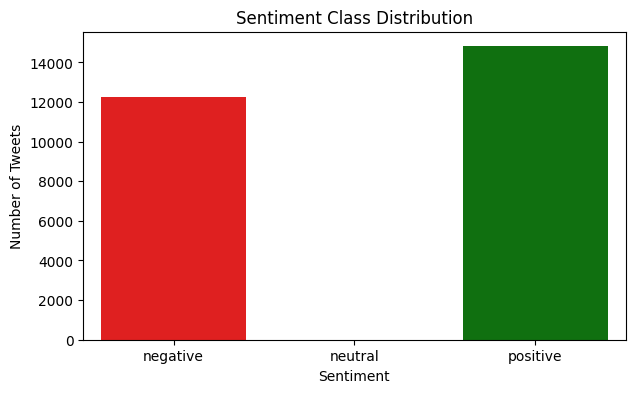

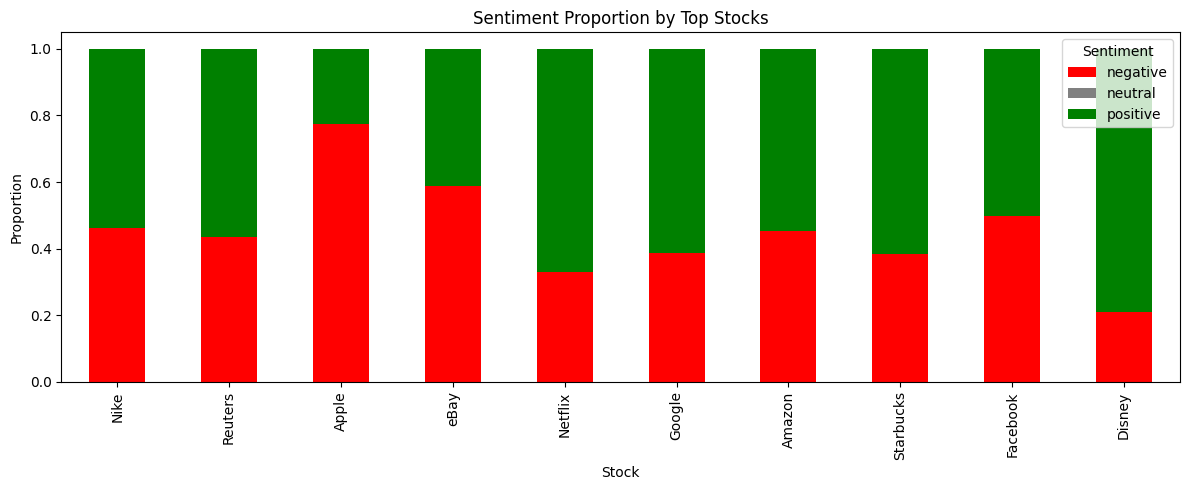

In [42]:
#  Sentiment EDA 
sentiment_order = ['negative', 'neutral', 'positive']
sentiment_colors = {
    'negative': 'red',
    'neutral': 'grey',
    'positive': 'green'
}
sentiment_counts = df['sentiment_label'].value_counts().reindex(sentiment_order).fillna(0).astype(int)

print("Sentiment distribution:")
print(sentiment_counts)
print("\nSentiment percentage:")
print((sentiment_counts / sentiment_counts.sum() * 100).round(2))

plt.figure(figsize=(7, 4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=[sentiment_colors[label] for label in sentiment_counts.index])
plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()

if 'STOCK' in df.columns:
    stock_sentiment = pd.crosstab(df['STOCK'], df['sentiment_label'], normalize='index')
    top_stocks = df['STOCK'].value_counts().head(10).index
    stock_sentiment.loc[top_stocks, sentiment_order].plot(kind='bar', stacked=True, figsize=(12, 5), color=[sentiment_colors[label] for label in sentiment_order])
    plt.title('Sentiment Proportion by Top Stocks')
    plt.xlabel('Stock')
    plt.ylabel('Proportion')
    plt.legend(title='Sentiment')
    plt.tight_layout()
    plt.show()


# Opinion Mining

## Opinion Word Extraction

In [43]:
#  Opinion Word Extraction 
# Opinion words are sentiment-bearing terms. We combine a finance-aware mini lexicon with VADER if available.

positive_lexicon = {
    'good', 'great', 'excellent', 'strong', 'growth', 'gain', 'gains', 'up', 'bullish',
    'profit', 'profits', 'beat', 'beats', 'buy', 'rally', 'surge', 'positive', 'improve'
}
negative_lexicon = {
    'bad', 'poor', 'weak', 'loss', 'losses', 'down', 'bearish', 'drop', 'fall', 'falls',
    'miss', 'misses', 'sell', 'crash', 'risk', 'negative', 'decline', 'lawsuit', 'debt'
}
opinion_lexicon = positive_lexicon.union(negative_lexicon)

try:
    from nltk.sentiment import SentimentIntensityAnalyzer
    vader = SentimentIntensityAnalyzer()
except Exception:
    vader = None

def extract_opinion_words(tokens):
    if not isinstance(tokens, list):
        return []
    extracted = []
    for token in tokens:
        token_lower = str(token).lower()
        if token_lower in opinion_lexicon:
            extracted.append(token_lower)
        elif vader is not None and abs(vader.polarity_scores(token_lower)['compound']) >= 0.3:
            extracted.append(token_lower)
    return sorted(set(extracted))

df['opinion_words'] = df['lemmatized_words'].apply(extract_opinion_words)

all_opinion_words = [word for words in df['opinion_words'] for word in words]
opinion_word_freq = Counter(all_opinion_words)
print("Top opinion words:")
print(pd.DataFrame(opinion_word_freq.most_common(20), columns=['opinion_word', 'frequency']))

df[['TWEET', 'sentiment_label', 'opinion_words']].head(10)


Top opinion words:
   opinion_word  frequency
0          like       1112
1          help        572
2        please        493
3         thank        474
4          love        465
5          good        456
6          dear        415
7        thanks        400
8         great        341
9           buy        327
10          win        312
11      support        279
12         free        276
13         best        225
14         care        209
15      special        199
16        laugh        195
17          yes        180
18       better        175
19          ill        167


,TWEET,sentiment_label,opinion_words
2,@FAME95FM1 Jamaicans make money with @Payoneer...,negative,[]
3,@CBSi Jamaicans make money with @Payoneer @Pay...,positive,[]
4,@Hitz92fm Jamaicans make money with @Payoneer ...,negative,[]
11,"RT @nikitakhara: Thank you, @Starbucks CEO for...",positive,"[thank, thanks]"
20,@gawker Jamaicans make money with @Payoneer @P...,negative,[]
23,RT @cultcommoncore: Dumping @Starbucks\r\r\r\r...,negative,"[crap, dumping, like]"
26,@amazon has your back when it comes to food sh...,negative,[]
35,"RT @nia4_trump: So instead of hiring 10,000 un...",negative,[spite]
48,Hmmm interesting... \r\r\r\r\r\r\nonly @IBM ha...,negative,[interesting]
53,RT @IndiaHistorypic: 1994::Young @sundarpichai...,negative,[]


## Opinion Target Extraction

In [44]:
# Opinion Target Extraction
# Opinion targets are the entities or noun phrases being discussed.
# Use a sample first because running spaCy over the full dataset can take a long time.

try:
    import spacy
    try:
        nlp = spacy.load('en_core_web_sm')
    except OSError:
        nlp = spacy.blank('en')
        nlp.add_pipe('sentencizer')
    SPACY_AVAILABLE = True
except Exception:
    nlp = None
    SPACY_AVAILABLE = False

company_terms = set(df['STOCK'].dropna().astype(str).str.lower().unique()) if 'STOCK' in df.columns else set()

def extract_opinion_targets(text, max_targets=6):
    text = str(text)
    targets = []
    if SPACY_AVAILABLE and nlp is not None:
        doc = nlp(text[:1000])
        if hasattr(doc, 'noun_chunks'):
            try:
                targets.extend([chunk.text.lower().strip() for chunk in doc.noun_chunks])
            except Exception:
                pass
        targets.extend([ent.text.lower().strip() for ent in doc.ents])
    else:
        tokens = word_tokenize(text)
        tagged = nltk.pos_tag(tokens)
        targets.extend([word.lower() for word, tag in tagged if tag.startswith('NN')])

    for term in company_terms:
        if term and term in text.lower():
            targets.append(term)

    cleaned_targets = []
    for target in targets:
        target = re.sub(r'[^a-zA-Z\s]', '', target).strip()
        if 2 <= len(target) <= 60 and target not in stop_words:
            cleaned_targets.append(target)
    return list(dict.fromkeys(cleaned_targets))[:max_targets]

# Sample first for faster experimentation.
opinion_sample_size = min(5000, len(df))
opinion_sample_df = df.sample(opinion_sample_size, random_state=42).copy()

opinion_sample_df['opinion_targets'] = opinion_sample_df['TWEET'].apply(extract_opinion_targets)

# Optional: store sample results back into df for rows that were processed.
df['opinion_targets'] = None
df.loc[opinion_sample_df.index, 'opinion_targets'] = opinion_sample_df['opinion_targets']

target_freq = Counter([target for targets in opinion_sample_df['opinion_targets'] for target in targets])
print(f"Opinion target extraction completed on {opinion_sample_size:,} sampled tweets.")
print("Top opinion targets:")
print(pd.DataFrame(target_freq.most_common(20), columns=['target', 'frequency']))

opinion_sample_df[['TWEET', 'opinion_words', 'opinion_targets']].head(10)


Opinion target extraction completed on 5,000 sampled tweets.
Top opinion targets:
                  target  frequency
0                   nike        550
1                   ebay        378
2             appleevent        253
3          iphone xs max        249
4                netflix        241
5                reuters        214
6                 google        207
7     apple watch series        203
8              iphone xr        200
9                 amazon        199
10  the allnew iphone xs        196
11                xs max        192
12            rt reuters        168
13                    us        142
14              facebook        134
15                 apple        117
16             starbucks        116
17              rt apple         79
18                disney         79
19            kaepernick         75


,TWEET,opinion_words,opinion_targets
88007,RT @DDJSMINDPALACE: Here's a meme for the mass...,[],"[a meme, the masses, donaldjtrumpjr, tuckercar..."
20496,RT @McDonalds: @KailynReagan What are you wait...,[],"[rt mcdonalds, some hash browns, your name, ka..."
71247,"@johnrich @Nike Ooooh, he sure showed Nike by ...","[destroying, strong, sure]","[nike, his own property, the dipshittery, trum..."
16259,RT @1VirtualPixie: WE SUPPORT CHUCK WOOLERY\r\...,[support],"[sponsorship, will r, rt virtualpixie, walmart]"
1555,@Starbucks I've never had the need to try Star...,"[boycotting, racist]","[the need, starb, racist, the quality, the pla..."
122552,RT @Reuters: ICYMI: Former Sesame Street write...,[friend],"[icymi, former sesame street writer mark saltz..."
3325,RT @EmoJoshy1: I really like what @pepsi is do...,"[fame, like]","[pepsi, lady gagas countdown, a look, her care..."
140666,"@Walmart - hey! Not to be a major pain, but Wa...",[pain],"[walmart, a major pain, walmart grocery app, t..."
65157,Check out Aluminum Cooking Canning Rack For Pr...,[],"[aluminum cooking canning rack, pressure canne..."
63732,RT @DFB_Team_EN: The DFB and @adidas have exte...,[],"[rt dfbteamen, the dfb, adidas, their longstan..."


## Dependancy Parsing

In [45]:
# Dependency Parsing for Explicit Opinion-Target Pairs
# When a spaCy statistical model is available, dependencies link opinion words to their targets.
# If only a blank spaCy model is available, a nearby-word fallback is used.

def extract_dependency_opinions(text):
    text = str(text)
    pairs = []

    if SPACY_AVAILABLE and nlp is not None and 'parser' in nlp.pipe_names:
        doc = nlp(text[:1000])
        for token in doc:
            token_lower = token.lemma_.lower() if token.lemma_ else token.text.lower()
            if token_lower in opinion_lexicon or (vader is not None and abs(vader.polarity_scores(token.text)['compound']) >= 0.3):
                linked_targets = []
                if token.head.pos_ in ['NOUN', 'PROPN']:
                    linked_targets.append(token.head.text.lower())
                linked_targets.extend([child.text.lower() for child in token.children if child.pos_ in ['NOUN', 'PROPN']])
                for target in linked_targets:
                    pairs.append({'opinion': token.text.lower(), 'target': target, 'dependency': token.dep_})
    else:
        tokens = [token.lower() for token in word_tokenize(text) if token.isalpha()]
        for index, token in enumerate(tokens):
            if token in opinion_lexicon:
                window = tokens[max(0, index - 4): index] + tokens[index + 1: index + 5]
                candidate_targets = [word for word in window if word not in stop_words and word not in opinion_lexicon]
                for target in candidate_targets[:2]:
                    pairs.append({'opinion': token, 'target': target, 'dependency': 'window_context'})

    return pairs[:6]

# Use the same sample from Opinion Target Extraction
dependency_df = opinion_sample_df.copy() if 'opinion_sample_df' in globals() else df.sample(min(5000, len(df)), random_state=42).copy()

dependency_df['opinion_target_pairs'] = dependency_df['TWEET'].apply(extract_dependency_opinions)

pair_rows = []
for _, row in dependency_df.iterrows():
    for pair in row['opinion_target_pairs']:
        pair_rows.append(pair)

opinion_pairs_df = pd.DataFrame(pair_rows)

print(f"Dependency parsing completed on {len(dependency_df):,} sampled tweets.")
print("Extracted opinion-target pairs:")
display(
    opinion_pairs_df.head(20)
    if not opinion_pairs_df.empty
    else pd.DataFrame(columns=['opinion', 'target', 'dependency'])
)

Dependency parsing completed on 5,000 sampled tweets.
Extracted opinion-target pairs:


,opinion,target,dependency
0,destroying,property,pcomp
1,support,@1virtualpixie,ROOT
2,support,@smartmouth,ROOT
3,boycotting,racist,conj
4,friends,reigni,pobj
5,like,rt,ROOT
6,original,@netflix,nsubj
7,suicide,vests,compound
8,lost,customers,ROOT
9,crazy,@realdockery,appos


# Aspect-Based Sentiment Analysis

## Aspect Extraction Using spaCy

In [46]:
# Aspect Extraction Using spaCy
# ABSA starts by extracting aspect candidates such as product, service, battery, screen, price, or stock-related terms.
# Reuse the opinion-mining sample so this section stays fast.

absa_df = opinion_sample_df.copy() if 'opinion_sample_df' in globals() else df.sample(min(5000, len(df)), random_state=42).copy()

finance_aspect_terms = {
    'price', 'share', 'stock', 'market', 'earnings', 'revenue', 'profit', 'loss', 'growth',
    'forecast', 'sales', 'volume', 'volatility', 'return', 'dividend', 'product', 'service'
}

def extract_aspects(text, max_aspects=5):
    targets = extract_opinion_targets(text, max_targets=10)
    aspects = []
    for target in targets:
        if any(term in target.split() for term in finance_aspect_terms) or len(target.split()) <= 3:
            aspects.append(target)
    if not aspects:
        tokens = [token for token in tokenize_text(clean_noise(text)) if token not in stop_words]
        aspects = [token for token in tokens if token in finance_aspect_terms]
    return list(dict.fromkeys(aspects))[:max_aspects]

absa_df['aspects'] = absa_df['TWEET'].apply(extract_aspects)

aspect_freq = Counter([aspect for aspects in absa_df['aspects'] for aspect in aspects])
print(f"Aspect extraction completed on {len(absa_df):,} sampled tweets.")
print("Top extracted aspects:")
print(pd.DataFrame(aspect_freq.most_common(20), columns=['aspect', 'frequency']))

absa_df[['TWEET', 'aspects']].head(10)


Aspect extraction completed on 5,000 sampled tweets.
Top extracted aspects:
                aspect  frequency
0                 nike        489
1                 ebay        356
2           appleevent        251
3        iphone xs max        246
4              netflix        217
5   apple watch series        203
6            iphone xr        200
7               xs max        192
8               google        189
9               amazon        183
10          rt reuters        168
11             reuters        153
12            facebook        124
13                  us        123
14               apple        105
15           starbucks         88
16            rt apple         79
17          kaepernick         72
18             walmart         68
19              disney         63


,TWEET,aspects
88007,RT @DDJSMINDPALACE: Here's a meme for the mass...,"[a meme, the masses, donaldjtrumpjr, tuckercar..."
20496,RT @McDonalds: @KailynReagan What are you wait...,"[rt mcdonalds, some hash browns, your name, ka..."
71247,"@johnrich @Nike Ooooh, he sure showed Nike by ...","[nike, his own property, the dipshittery, trum..."
16259,RT @1VirtualPixie: WE SUPPORT CHUCK WOOLERY\r\...,"[sponsorship, will r, rt virtualpixie, walmart]"
1555,@Starbucks I've never had the need to try Star...,"[the need, starb, racist, the quality, the place]"
122552,RT @Reuters: ICYMI: Former Sesame Street write...,"[icymi, a statement, bert, ernie, just friends]"
3325,RT @EmoJoshy1: I really like what @pepsi is do...,"[pepsi, lady gagas countdown, a look, her care..."
140666,"@Walmart - hey! Not to be a major pain, but Wa...","[walmart, a major pain, walmart grocery app, t..."
65157,Check out Aluminum Cooking Canning Rack For Pr...,"[pressure canner cooker, httpstcovwcmrpqrbx, e..."
63732,RT @DFB_Team_EN: The DFB and @adidas have exte...,"[rt dfbteamen, the dfb, adidas, their longstan..."


## Aspect Categorization

In [47]:
# Aspect Categorization
# Map noisy noun phrases into interpretable aspect categories.

aspect_category_keywords = {
    'Stock Performance': ['stock', 'share', 'price', 'return', 'market', 'rally', 'drop', 'volume'],
    'Financial Results': ['earnings', 'revenue', 'profit', 'loss', 'sales', 'dividend', 'quarter'],
    'Risk and Volatility': ['risk', 'volatility', 'debt', 'lawsuit', 'crash', 'decline'],
    'Product and Service': ['product', 'service', 'customer', 'quality', 'app', 'platform'],
    'Company News': ['company', 'ceo', 'deal', 'acquisition', 'launch', 'announcement']
}

def categorize_aspect(aspect):
    aspect_lower = str(aspect).lower()
    for category, keywords in aspect_category_keywords.items():
        if any(keyword in aspect_lower for keyword in keywords):
            return category
    return 'Other'

def categorize_aspects(aspects):
    return [{'aspect': aspect, 'category': categorize_aspect(aspect)} for aspect in aspects]

absa_df['aspect_categories'] = absa_df['aspects'].apply(categorize_aspects)

aspect_category_rows = []
for idx, row in absa_df.iterrows():
    for item in row['aspect_categories']:
        aspect_category_rows.append({
            'tweet_index': idx,
            'aspect': item['aspect'],
            'category': item['category'],
            'sentiment_label': row['sentiment_label']
        })

aspect_category_df = pd.DataFrame(aspect_category_rows)
print("Aspect category distribution:")
display(aspect_category_df['category'].value_counts().to_frame('count') if not aspect_category_df.empty else pd.DataFrame())


Aspect category distribution:


,count
category,
Other,21388
Product and Service,940
Company News,137
Stock Performance,118
Financial Results,65
Risk and Volatility,12


## Aspect Sentiment Classification

In [48]:
#  Aspect Sentiment Classification 
# Each extracted aspect inherits context from the tweet and is assigned sentiment.
# A lightweight lexicon score is always available; an optional BERT-style transformer pipeline is used when installed.

try:
    from transformers import pipeline
    aspect_sentiment_pipeline = pipeline('sentiment-analysis', model='distilbert-base-uncased-finetuned-sst-2-english')
except Exception:
    aspect_sentiment_pipeline = None

def score_aspect_context(text, aspect):
    text = str(text)
    aspect = str(aspect)
    context = f"Aspect: {aspect}. Review: {text}"

    if vader is not None:
        score = vader.polarity_scores(context)['compound']
    else:
        opinion_words = extract_opinion_words(tokenize_text(clean_noise(context)))
        score = sum(1 for word in opinion_words if word in positive_lexicon) - sum(1 for word in opinion_words if word in negative_lexicon)
        score = score / max(len(opinion_words), 1)

    lexicon_label = polarity_to_sentiment(score, threshold=0.05)

    transformer_label = None
    transformer_score = None
    if aspect_sentiment_pipeline is not None:
        try:
            result = aspect_sentiment_pipeline(context[:512])[0]
            transformer_label = 'positive' if result['label'].upper().startswith('POS') else 'negative'
            transformer_score = result['score']
        except Exception:
            transformer_label = None
            transformer_score = None

    return {
        'aspect': aspect,
        'lexicon_score': score,
        'lexicon_sentiment': lexicon_label,
        'bert_absa_sentiment': transformer_label if transformer_label is not None else lexicon_label,
        'bert_absa_confidence': transformer_score
    }

def classify_aspect_sentiments(row):
    return [score_aspect_context(row['TWEET'], aspect) for aspect in row['aspects']]

absa_df['aspect_sentiments'] = absa_df.apply(classify_aspect_sentiments, axis=1)

aspect_sentiment_rows = []
for idx, row in absa_df.iterrows():
    for item in row['aspect_sentiments']:
        aspect_sentiment_rows.append({
            'tweet_index': idx,
            'aspect': item['aspect'],
            'category': categorize_aspect(item['aspect']),
            'sentiment': item['bert_absa_sentiment'],
            'lexicon_score': item['lexicon_score'],
            'confidence': item['bert_absa_confidence']
        })

aspect_sentiment_df = pd.DataFrame(aspect_sentiment_rows)
display(aspect_sentiment_df.head(20) if not aspect_sentiment_df.empty else pd.DataFrame())


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 4795.55it/s]
[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,tweet_index,aspect,category,sentiment,lexicon_score,confidence
0,88007,a meme,Other,positive,0.0000,0.703344
1,88007,the masses,Other,negative,0.0000,0.812358
2,88007,donaldjtrumpjr,Other,negative,0.0000,0.934669
3,88007,tuckercarlson,Other,negative,0.0000,0.729793
4,88007,httpstco,Other,negative,0.0000,0.921196
5,20496,rt mcdonalds,Other,negative,0.0000,0.981985
6,20496,some hash browns,Other,negative,0.0000,0.981515
7,20496,your name,Other,negative,0.0000,0.977410
8,20496,kail,Other,negative,0.0000,0.949558
9,20496,hash browns,Other,negative,0.0000,0.979951


## Aspect-Wise Sentiment Visualisation

sentiment,negative,neutral,positive
category,,,
Company News,75,0,62
Financial Results,38,0,27
Other,14475,0,6913
Product and Service,789,0,151
Risk and Volatility,11,0,1
Stock Performance,95,0,23


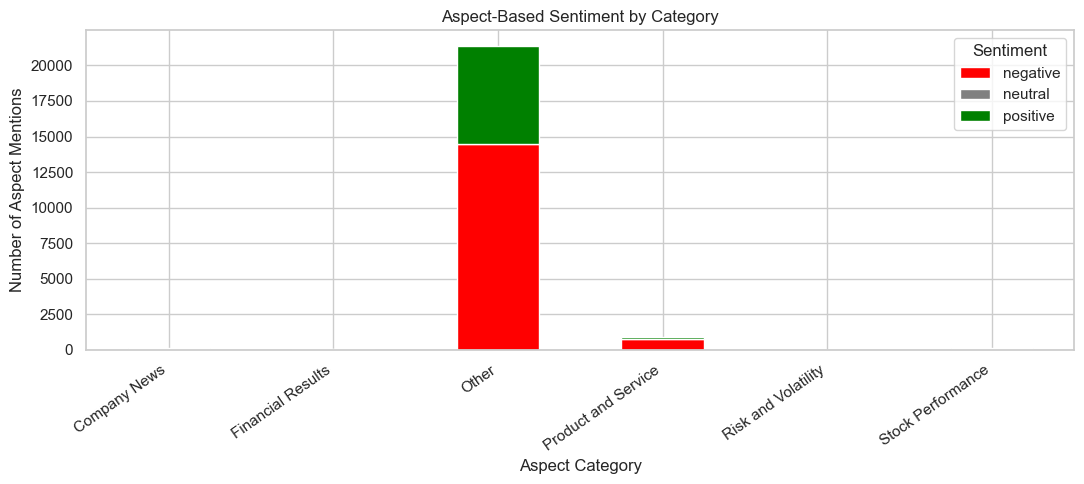

In [72]:
if not aspect_sentiment_df.empty:
    aspect_sentiment_summary = pd.crosstab(
        aspect_sentiment_df['category'],
        aspect_sentiment_df['sentiment']
    ).reindex(columns=sentiment_order, fill_value=0)

    display(aspect_sentiment_summary)

    aspect_sentiment_summary.plot(
        kind='bar',
        stacked=True,
        figsize=(11, 5),
        color=[sentiment_colors[label] for label in aspect_sentiment_summary.columns]
    )

    plt.title('Aspect-Based Sentiment by Category')
    plt.xlabel('Aspect Category')
    plt.ylabel('Number of Aspect Mentions')
    plt.xticks(rotation=35, ha='right')
    plt.legend(title='Sentiment')
    plt.tight_layout()
    plt.show()
else:
    print("No aspect sentiments were extracted. Check aspect extraction output above.")

# Modelling

- Feature selection
- Train-test split
- Model training
- Model evaluation

In [50]:
#  Shared Modelling Setup 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

full_model_df = df[['TWEET', 'joined_tokens', 'sentiment_label']].dropna().copy()
model_df = full_model_df.reset_index(drop=True)

print(f"Total labelled rows available: {len(full_model_df):,}")
print(f"Rows used for ML/DL modelling (50% sample): {len(model_df):,}")
print("Class distribution used for modelling:")
print(model_df['sentiment_label'].value_counts())

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(model_df['sentiment_label'])
class_names = label_encoder.classes_

X_train_text, X_test_text, y_train, y_test = train_test_split(
    model_df['joined_tokens'].fillna('').astype(str),
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

raw_train_text = model_df.loc[X_train_text.index, 'TWEET'].astype(str)
raw_test_text = model_df.loc[X_test_text.index, 'TWEET'].astype(str)

model_results = []
model_predictions = {}
model_truths = {}

def evaluate_model(model_name, model_type, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    model_results.append({
        'Model': model_name,
        'Type': model_type,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })
    model_predictions[model_name] = y_pred
    model_truths[model_name] = y_true
    print(f"\n{model_name}")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

print(f"Training rows: {len(X_train_text):,}")
print(f"Testing rows : {len(X_test_text):,}")
print(f"Classes      : {list(class_names)}")


Total labelled rows available: 27,084
Rows used for ML/DL modelling (50% sample): 27,084
Class distribution used for modelling:
sentiment_label
positive    14808
negative    12270
neutral         6
Name: count, dtype: int64
Training rows: 21,667
Testing rows : 5,417
Classes      : ['negative', 'neutral', 'positive']


## Lexicon-Based Sentiment Model - VADER


In [51]:
# --- Lexicon-Based Sentiment Model: VADER ---
# VADER is a rule/lexicon-based sentiment model that scores text using sentiment dictionaries and heuristics.
# It does not learn from the training data, so it provides a useful baseline against ML, DL, and transformers.

try:
    from nltk.sentiment import SentimentIntensityAnalyzer
    vader_model = SentimentIntensityAnalyzer()
    LEXICON_MODEL_NAME = 'VADER Lexicon'

    def lexicon_predict_label(text):
        score = vader_model.polarity_scores(str(text))['compound']
        return polarity_to_sentiment(score, threshold=0.05)

except Exception:
    from textblob import TextBlob
    LEXICON_MODEL_NAME = 'TextBlob Lexicon'

    def lexicon_predict_label(text):
        score = TextBlob(str(text)).sentiment.polarity
        return polarity_to_sentiment(score, threshold=0.05)

lexicon_pred_labels = raw_test_text.apply(lexicon_predict_label)
lexicon_predictions = label_encoder.transform(lexicon_pred_labels)

evaluate_model(LEXICON_MODEL_NAME, 'Lexicon-Based', y_test, lexicon_predictions)



VADER Lexicon
              precision    recall  f1-score   support

    negative       0.53      0.25      0.34      2454
     neutral       0.00      0.00      0.00         1
    positive       0.65      0.50      0.57      2962

    accuracy                           0.39      5417
   macro avg       0.39      0.25      0.30      5417
weighted avg       0.60      0.39      0.46      5417



## Traditional ML Models - Logistic Regression, SVM, Random Forest


In [52]:
# Traditional Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

traditional_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Linear SVM': LinearSVC(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=150, class_weight='balanced', random_state=42, n_jobs=-1)
}

trained_traditional_models = {}
for model_name, classifier in traditional_models.items():
    pipeline_model = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)),
        ('classifier', classifier)
    ])
    pipeline_model.fit(X_train_text, y_train)
    predictions = pipeline_model.predict(X_test_text)
    trained_traditional_models[model_name] = pipeline_model
    evaluate_model(model_name, 'Traditional ML', y_test, predictions)



Logistic Regression
              precision    recall  f1-score   support

    negative       0.71      0.73      0.72      2454
     neutral       0.02      1.00      0.04         1
    positive       0.78      0.74      0.76      2962

    accuracy                           0.74      5417
   macro avg       0.50      0.82      0.51      5417
weighted avg       0.75      0.74      0.74      5417


Linear SVM
              precision    recall  f1-score   support

    negative       0.72      0.72      0.72      2454
     neutral       0.03      1.00      0.05         1
    positive       0.77      0.76      0.77      2962

    accuracy                           0.74      5417
   macro avg       0.51      0.83      0.51      5417
weighted avg       0.75      0.74      0.75      5417


Random Forest
              precision    recall  f1-score   support

    negative       0.76      0.73      0.75      2454
     neutral       0.01      1.00      0.03         1
    positive       0.79    

## Deep Learning Models - LSTM and BiLSTM


In [53]:
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)

max_words = 12000
max_len = 60
num_classes = len(class_names)

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_train_text),
    maxlen=max_len,
    padding="post",
    truncating="post"
)

X_test_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_test_text),
    maxlen=max_len,
    padding="post",
    truncating="post"
)

# Stratified validation split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_seq,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Class weights help minority classes, especially neutral
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight = dict(zip(classes, weights))
print("Class weights:", class_weight)


def build_lstm_model(
    bidirectional=False,
    embedding_dim=64,
    lstm_units=64,
    dense_units=64,
    dropout_rate=0.3,
    recurrent_dropout=0.0,
    learning_rate=0.001
):
    model = Sequential()
    model.add(Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len))
    model.add(SpatialDropout1D(dropout_rate))

    lstm_layer = LSTM(
        lstm_units,
        dropout=dropout_rate,
        recurrent_dropout=recurrent_dropout
    )

    if bidirectional:
        model.add(Bidirectional(lstm_layer))
    else:
        model.add(lstm_layer)

    model.add(Dense(dense_units, activation="relu"))
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


param_grid = {
    "embedding_dim": [128],
    "lstm_units": [64, 128],
    "dense_units": [64],
    "dropout_rate": [0.3],
    "learning_rate": [0.001],
    "batch_size": [64]
}

best_models = {}

for model_type, is_bilstm in {
    "LSTM": False,
    "BiLSTM": True
}.items():

    print(f"\nTuning {model_type}...")

    best_val_f1  = 0
    best_model = None
    best_params = None

    for params in ParameterGrid(param_grid):
        print(f"\nTrying params: {params}")

        model = build_lstm_model(
            bidirectional=is_bilstm,
            embedding_dim=params["embedding_dim"],
            lstm_units=params["lstm_units"],
            dense_units=params["dense_units"],
            dropout_rate=params["dropout_rate"],
            learning_rate=params["learning_rate"]
        )

        history = model.fit(
            X_tr,
            y_tr,
            validation_data=(X_val, y_val),
            epochs=10,
            batch_size=params["batch_size"],
            class_weight=class_weight,
            callbacks=[
                EarlyStopping(
                    monitor="val_loss",
                    patience=3,
                    restore_best_weights=True
                ),
                ReduceLROnPlateau(
                    monitor="val_loss",
                    factor=0.5,
                    patience=1,
                    min_lr=1e-5
                )
            ],
            verbose=1
        )

        val_probs = model.predict(X_val, verbose=0)
        val_preds = np.argmax(val_probs, axis=1)
        val_f1 = f1_score(y_val, val_preds, average="macro", zero_division=0)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model = model
            best_params = params

    print(f"\nBest {model_type} params:", best_params)
    print(f"Best {model_type} validation macro F1:", best_val_f1)
    probabilities = best_model.predict(X_test_seq, verbose=0)
    predictions = np.argmax(probabilities, axis=1)

    best_models[model_type] = best_model
    evaluate_model(model_type, "Deep Learning Tuned", y_test, predictions)

Class weights: {np.int64(0): np.float64(0.7357715294756859), np.int64(1): np.float64(1444.4666666666667), np.int64(2): np.float64(0.6096854071697901)}

Tuning LSTM...

Trying params: {'batch_size': 64, 'dense_units': 64, 'dropout_rate': 0.3, 'embedding_dim': 128, 'learning_rate': 0.001, 'lstm_units': 64}
Epoch 1/10


c:\Users\hafiz\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


271/271 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.5003 - loss: 2.1564 - val_accuracy: 0.4529 - val_loss: 0.7101 - learning_rate: 0.0010
Epoch 2/10
271/271 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.5024 - loss: 1.8569 - val_accuracy: 0.4529 - val_loss: 0.7075 - learning_rate: 0.0010
Epoch 3/10
271/271 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.4903 - loss: 1.9161 - val_accuracy: 0.4529 - val_loss: 0.7427 - learning_rate: 0.0010
Epoch 4/10
271/271 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.4625 - loss: 1.6477 - val_accuracy: 0.4529 - val_loss: 0.7759 - learning_rate: 5.0000e-04
Epoch 5/10
271/271 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.4602 - loss: 1.5244 - val_accuracy: 0.4529 - val_loss: 0.8019 - learning_rate: 2.5000e-04

Trying params: {'batch_size': 64, 'dense_units': 64, 'dropout_rate': 0.3, 'embedding_dim': 128, 'learning_rate': 0.001, 'lstm_units': 128}
Epoch 1/10


c:\Users\hafiz\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


271/271 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.5052 - loss: 2.3366 - val_accuracy: 0.5468 - val_loss: 0.6947 - learning_rate: 0.0010
Epoch 2/10
271/271 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.5014 - loss: 2.2691 - val_accuracy: 0.5468 - val_loss: 0.7309 - learning_rate: 0.0010
Epoch 3/10
271/271 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.5155 - loss: 1.6796 - val_accuracy: 0.5468 - val_loss: 0.8403 - learning_rate: 5.0000e-04
Epoch 4/10
271/271 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.5356 - loss: 1.3263 - val_accuracy: 0.5468 - val_loss: 0.8537 - learning_rate: 2.5000e-04

Best LSTM params: {'batch_size': 64, 'dense_units': 64, 'dropout_rate': 0.3, 'embedding_dim': 128, 'learning_rate': 0.001, 'lstm_units': 128}
Best LSTM validation macro F1: 0.2356801909307876

LSTM
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00      2454
     neutral       0.00      0.00      0.00         1
    positive       0.55  

c:\Users\hafiz\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


271/271 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.6356 - loss: 2.0763 - val_accuracy: 0.7234 - val_loss: 0.5321 - learning_rate: 0.0010
Epoch 2/10
271/271 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.7430 - loss: 1.5015 - val_accuracy: 0.7420 - val_loss: 0.5090 - learning_rate: 0.0010
Epoch 3/10
271/271 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.7922 - loss: 1.2924 - val_accuracy: 0.7379 - val_loss: 0.5688 - learning_rate: 0.0010
Epoch 4/10
271/271 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.8244 - loss: 0.5430 - val_accuracy: 0.7314 - val_loss: 0.6048 - learning_rate: 5.0000e-04
Epoch 5/10
271/271 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.8491 - loss: 0.4050 - val_accuracy: 0.7310 - val_loss: 0.6223 - learning_rate: 2.5000e-04

Trying params: {'batch_size': 64, 'dense_units': 64, 'dropout_rate': 0.3, 'embedding_dim': 128, 'learning_rate': 0.001, 'lstm_units': 128}
Epoch 1/10


c:\Users\hafiz\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


271/271 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step - accuracy: 0.6488 - loss: 1.9330 - val_accuracy: 0.7245 - val_loss: 0.5266 - learning_rate: 0.0010
Epoch 2/10
271/271 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.7496 - loss: 1.2823 - val_accuracy: 0.7377 - val_loss: 0.5139 - learning_rate: 0.0010
Epoch 3/10
271/271 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.7534 - loss: 1.1828 - val_accuracy: 0.7298 - val_loss: 0.5631 - learning_rate: 0.0010
Epoch 4/10
271/271 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.8147 - loss: 0.4625 - val_accuracy: 0.7300 - val_loss: 0.5943 - learning_rate: 5.0000e-04
Epoch 5/10
271/271 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.8449 - loss: 0.3816 - val_accuracy: 0.7358 - val_loss: 0.6134 - learning_rate: 2.5000e-04

Best BiLSTM params: {'batch_size': 64, 'dense_units': 64, 'dropout_rate': 0.3, 'embedding_dim': 128, 'learning_rate': 0.001, 'lstm_units': 64}
Best BiLSTM validation macro F1: 0.49286319545696045

BiLSTM
              precision    r

## Transformer Models - BERT and RoBERTa


In [62]:
try:
    import torch
    import numpy as np

    from torch.utils.data import Dataset as TorchDataset
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score
    from transformers import (
        AutoTokenizer,
        AutoModelForSequenceClassification,
        TrainingArguments,
        Trainer,
        EarlyStoppingCallback
    )

    TRANSFORMERS_AVAILABLE = True
except Exception as exc:
    TRANSFORMERS_AVAILABLE = False
    print(f"Transformers stack is not available, skipping transformer models: {exc}")


class TweetSentimentDataset(TorchDataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            list(texts),
            padding=True,
            truncation=True,
            max_length=max_length
        )
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


def compute_transformer_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted",
        zero_division=0
    )

    precision_m, recall_m, f1_m, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy_score(labels, preds),
        "weighted_precision": precision_w,
        "weighted_recall": recall_w,
        "weighted_f1": f1_w,
        "macro_precision": precision_m,
        "macro_recall": recall_m,
        "macro_f1": f1_m
    }


if TRANSFORMERS_AVAILABLE:
    tr_train_text, tr_val_text, tr_train_y, tr_val_y = train_test_split(
        raw_train_text.astype(str),
        y_train,
        test_size=0.15,
        random_state=42,
        stratify=y_train
    )

    transformer_specs = {
        "BERT": "distilbert-base-uncased",
        "RoBERTa": "distilroberta-base"
    }

    trained_transformer_models = {}

    for model_name, checkpoint in transformer_specs.items():
        print(f"\nFine-tuning {model_name} ({checkpoint})...")

        tokenizer = AutoTokenizer.from_pretrained(checkpoint)

        train_dataset = TweetSentimentDataset(
            tr_train_text.tolist(),
            tr_train_y,
            tokenizer,
            max_length=128
        )

        val_dataset = TweetSentimentDataset(
            tr_val_text.tolist(),
            tr_val_y,
            tokenizer,
            max_length=128
        )

        test_dataset = TweetSentimentDataset(
            raw_test_text.astype(str).tolist(),
            y_test,
            tokenizer,
            max_length=128
        )

        model = AutoModelForSequenceClassification.from_pretrained(
            checkpoint,
            num_labels=len(class_names),
            id2label={i: label for i, label in enumerate(class_names)},
            label2id={label: i for i, label in enumerate(class_names)}
        )

        training_args = TrainingArguments(
            output_dir=f"./{model_name.lower()}_sentiment_results",

            num_train_epochs=4,
            per_device_train_batch_size=16,
            per_device_eval_batch_size=32,
            learning_rate=2e-5,
            weight_decay=0.01,
            warmup_ratio=0.1,

            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="macro_f1",
            greater_is_better=True,

            logging_steps=50,
            save_total_limit=1,
            report_to="none",
            seed=42,

            fp16=torch.cuda.is_available()
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            compute_metrics=compute_transformer_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
        )

        trainer.train()

        output = trainer.predict(test_dataset)
        predictions = np.argmax(output.predictions, axis=1)

        trained_transformer_models[model_name] = {
            "trainer": trainer,
            "tokenizer": tokenizer,
            "checkpoint": checkpoint
        }

        evaluate_model(
            model_name,
            "Transformer Tuned",
            y_test,
            predictions
        )


Fine-tuning BERT (distilbert-base-uncased)...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 10642.74it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1
1,0.521387,0.495435,0.752691,0.751930,0.752691,0.752030,0.500580,0.499275,0.499738
2,0.384448,0.449784,0.784989,0.789813,0.784989,0.785343,0.523620,0.525437,0.523146
3,0.251315,0.558933,0.787758,0.787739,0.787758,0.786495,0.525498,0.521589,0.522690
4,0.136402,0.712094,0.792372,0.791855,0.792372,0.792039,0.527188,0.526570,0.526829


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.61it/s]



BERT
              precision    recall  f1-score   support

    negative       0.77      0.77      0.77      2454
     neutral       0.00      0.00      0.00         1
    positive       0.81      0.81      0.81      2962

    accuracy                           0.79      5417
   macro avg       0.53      0.53      0.53      5417
weighted avg       0.79      0.79      0.79      5417


Fine-tuning RoBERTa (distilroberta-base)...


Loading weights: 100%|██████████| 101/101 [00:00<00:00, 4617.67it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_rati

Epoch,Training Loss,Validation Loss,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1
1,0.541577,0.547987,0.729006,0.728893,0.729006,0.726469,0.486138,0.480921,0.481838
2,0.482939,0.466604,0.767149,0.767358,0.767149,0.767198,0.510090,0.510763,0.510389
3,0.315145,0.543517,0.780068,0.779999,0.780068,0.778754,0.520293,0.516396,0.517473
4,0.262819,0.623863,0.777607,0.776988,0.777607,0.776928,0.517605,0.515902,0.516503


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.80it/s]



RoBERTa
              precision    recall  f1-score   support

    negative       0.77      0.73      0.75      2454
     neutral       0.00      0.00      0.00         1
    positive       0.78      0.82      0.80      2962

    accuracy                           0.78      5417
   macro avg       0.52      0.51      0.52      5417
weighted avg       0.78      0.78      0.78      5417



In [55]:
import sys
print(sys.executable)

c:\Users\hafiz\AppData\Local\Programs\Python\Python313\python.exe


# Model Evaluation

## Accuracy, Precision, Recall and F1-Score

This section evaluates every trained model using both weighted and macro metrics. Weighted metrics reflect overall performance across the dataset, while macro metrics give equal importance to each sentiment class and are therefore useful for checking whether minority classes such as neutral are being handled well.


In [63]:
sns.set_theme(style='whitegrid')
evaluation_rows = []

if len(model_predictions) == 0:
    print('No model predictions available yet. Run the modelling cells first.')
else:
    for model_name, y_pred in model_predictions.items():
        y_true = np.asarray(model_truths[model_name])
        y_pred = np.asarray(y_pred)

        weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average='weighted', zero_division=0
        )
        macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average='macro', zero_division=0
        )

        model_type = 'Unknown'
        if len(model_results) > 0:
            matching_rows = [row for row in model_results if row['Model'] == model_name]
            if matching_rows:
                model_type = matching_rows[-1].get('Type', 'Unknown')

        evaluation_rows.append({
            'Model': model_name,
            'Type': model_type,
            'Accuracy': accuracy_score(y_true, y_pred),
            'Weighted Precision': weighted_precision,
            'Weighted Recall': weighted_recall,
            'Weighted F1': weighted_f1,
            'Macro Precision': macro_precision,
            'Macro Recall': macro_recall,
            'Macro F1': macro_f1
        })

    evaluation_df = (
        pd.DataFrame(evaluation_rows)
        .sort_values(['Macro F1', 'Weighted F1', 'Accuracy'], ascending=False)
        .reset_index(drop=True)
    )

    display(evaluation_df.style.format({
        'Accuracy': '{:.4f}',
        'Weighted Precision': '{:.4f}',
        'Weighted Recall': '{:.4f}',
        'Weighted F1': '{:.4f}',
        'Macro Precision': '{:.4f}',
        'Macro Recall': '{:.4f}',
        'Macro F1': '{:.4f}'
    }).background_gradient(subset=['Accuracy', 'Weighted F1', 'Macro F1'], cmap='YlGnBu'))


,Model,Type,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1
0,BERT,Transformer Tuned,0.7903,0.7901,0.7903,0.7902,0.5256,0.5257,0.5257
1,Random Forest,Traditional ML,0.7691,0.7794,0.7691,0.7739,0.5232,0.8437,0.5230
2,RoBERTa,Transformer Tuned,0.7766,0.7761,0.7766,0.7759,0.5171,0.5149,0.5157
3,Linear SVM,Traditional ML,0.7425,0.7480,0.7425,0.7451,0.5054,0.8271,0.5117
4,Logistic Regression,Traditional ML,0.7375,0.7456,0.7375,0.7411,0.5015,0.8247,0.5058
5,BiLSTM,Deep Learning Tuned,0.7312,0.7316,0.7312,0.7313,0.4860,0.4865,0.4862
6,VADER Lexicon,Lexicon-Based,0.3880,0.5969,0.3880,0.4646,0.3942,0.2510,0.3028
7,LSTM,Deep Learning Tuned,0.5468,0.2990,0.5468,0.3866,0.1823,0.3333,0.2357


## Classification Reports

The classification reports show per-class precision, recall and F1-score. This is especially important for this project because a model can achieve reasonable accuracy while still failing to recognise negative or neutral sentiment.


In [64]:
if len(model_predictions) == 0:
    print('No model predictions available yet. Run the modelling cells first.')
else:
    for model_name in evaluation_df['Model']:
        print('=' * 90)
        print(f'Classification Report: {model_name}')
        print('=' * 90)
        print(classification_report(
            model_truths[model_name],
            model_predictions[model_name],
            target_names=class_names,
            zero_division=0
        ))


Classification Report: BERT
              precision    recall  f1-score   support

    negative       0.77      0.77      0.77      2454
     neutral       0.00      0.00      0.00         1
    positive       0.81      0.81      0.81      2962

    accuracy                           0.79      5417
   macro avg       0.53      0.53      0.53      5417
weighted avg       0.79      0.79      0.79      5417

Classification Report: Random Forest
              precision    recall  f1-score   support

    negative       0.76      0.73      0.75      2454
     neutral       0.01      1.00      0.03         1
    positive       0.79      0.80      0.80      2962

    accuracy                           0.77      5417
   macro avg       0.52      0.84      0.52      5417
weighted avg       0.78      0.77      0.77      5417

Classification Report: RoBERTa
              precision    recall  f1-score   support

    negative       0.77      0.73      0.75      2454
     neutral       0.00      0.00

## Confusion Matrices

Confusion matrices make the model behaviour easier to interpret by showing which sentiment classes are being confused with each other.


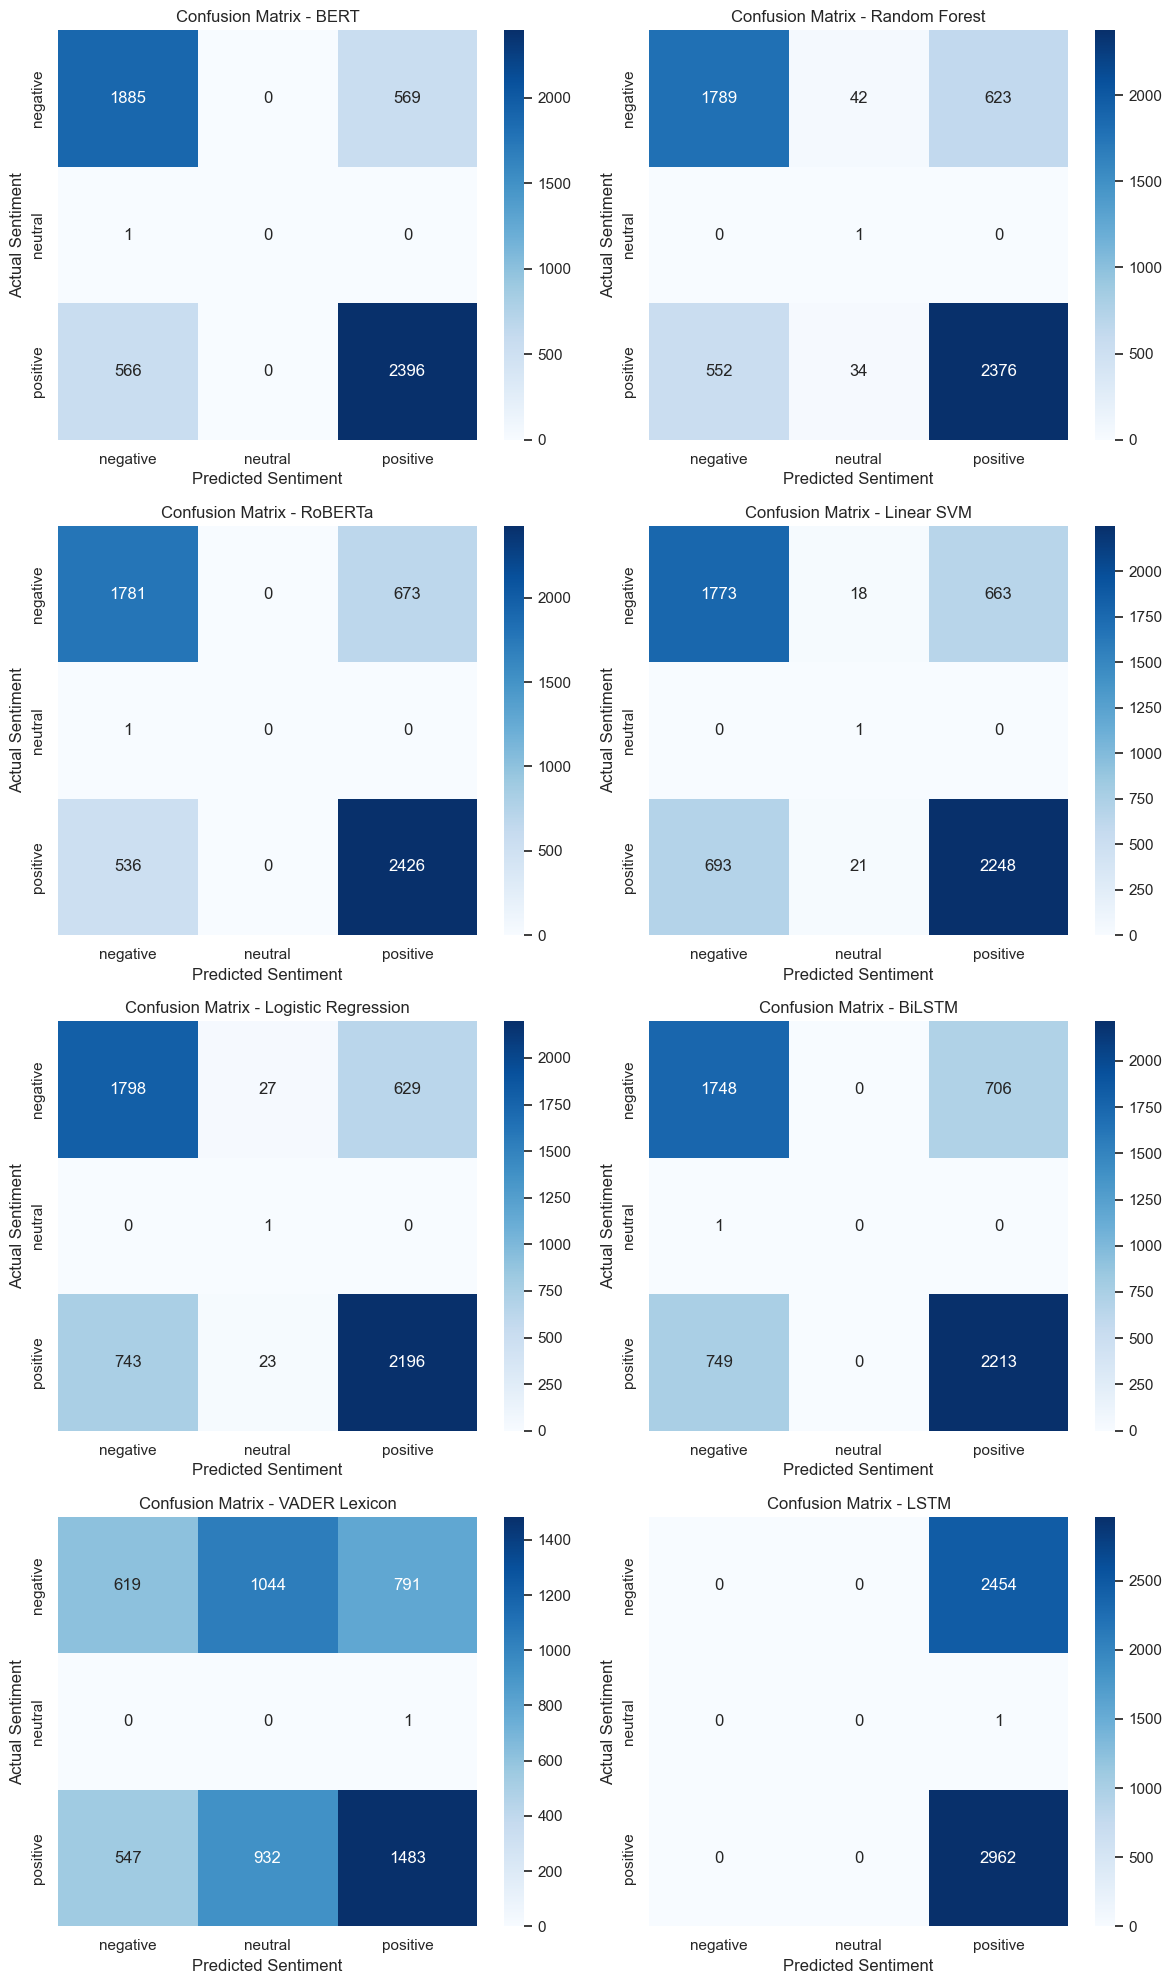

In [65]:
if len(model_predictions) == 0:
    print('No model predictions available yet. Run the modelling cells first.')
else:
    n_models = len(evaluation_df)
    n_cols = 2
    n_rows = int(np.ceil(n_models / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, model_name in zip(axes, evaluation_df['Model']):
        cm = confusion_matrix(model_truths[model_name], model_predictions[model_name])
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            ax=ax
        )
        ax.set_title(f'Confusion Matrix - {model_name}')
        ax.set_xlabel('Predicted Sentiment')
        ax.set_ylabel('Actual Sentiment')

    for ax in axes[len(evaluation_df):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


# Model Comparison

The model comparison ranks all approaches by macro F1, weighted F1 and accuracy. Macro F1 is the main selection metric because it rewards models that perform well across all sentiment classes instead of only favouring the majority class.


Model ranking by Macro F1:


,Model,Type,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro F1
0,BERT,Transformer Tuned,0.7903,0.7901,0.7903,0.7902,0.5257
1,Random Forest,Traditional ML,0.7691,0.7794,0.7691,0.7739,0.5230
2,RoBERTa,Transformer Tuned,0.7766,0.7761,0.7766,0.7759,0.5157
3,Linear SVM,Traditional ML,0.7425,0.7480,0.7425,0.7451,0.5117
4,Logistic Regression,Traditional ML,0.7375,0.7456,0.7375,0.7411,0.5058
5,BiLSTM,Deep Learning Tuned,0.7312,0.7316,0.7312,0.7313,0.4862
6,VADER Lexicon,Lexicon-Based,0.3880,0.5969,0.3880,0.4646,0.3028
7,LSTM,Deep Learning Tuned,0.5468,0.2990,0.5468,0.3866,0.2357


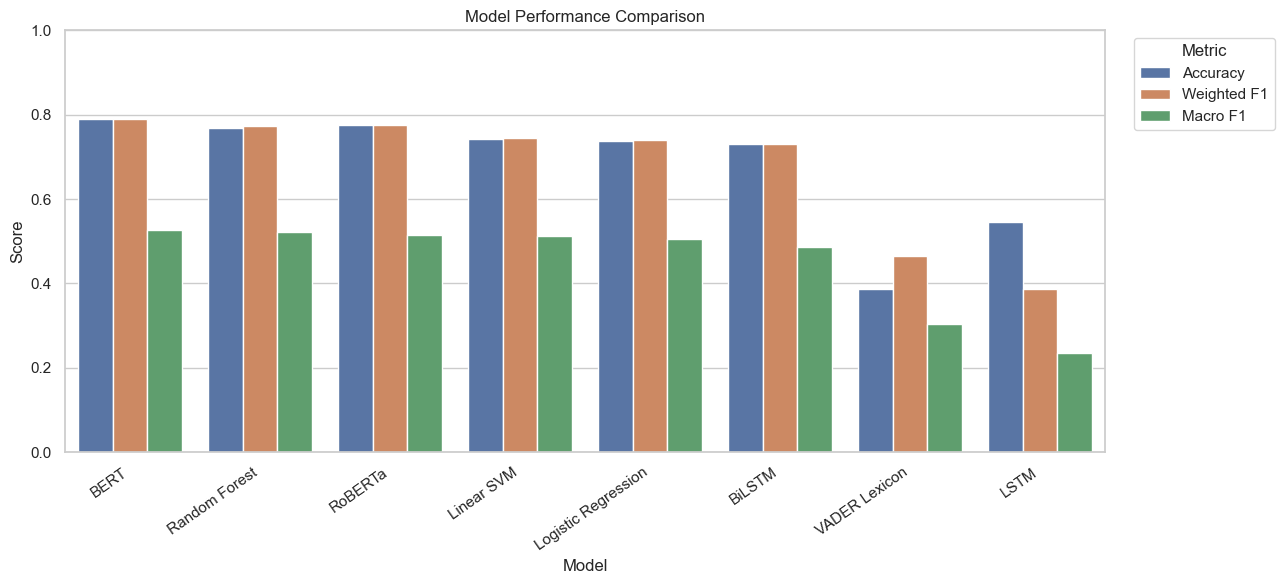

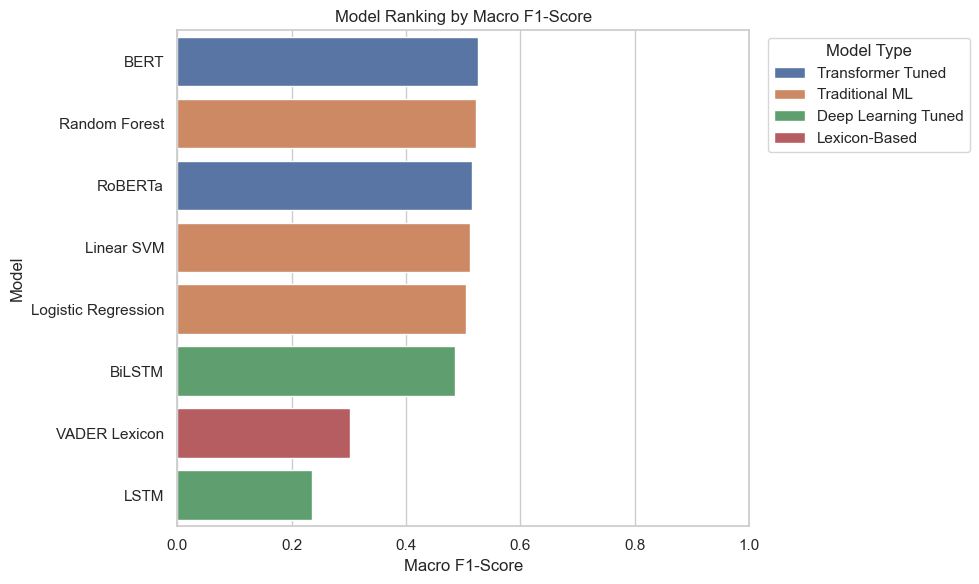

Best Performing Model
---------------------------------------------
Model       : BERT
Type        : Transformer Tuned
Accuracy    : 0.7903
Weighted F1 : 0.7902
Macro F1    : 0.5257


In [66]:
# =========================
# Model Comparison
# =========================

if 'evaluation_df' not in globals() or evaluation_df.empty:
    print('No evaluation results available yet. Run the model evaluation cell first.')
else:
    comparison_df = evaluation_df.copy()

    metric_cols = ['Accuracy', 'Weighted Precision', 'Weighted Recall', 'Weighted F1', 'Macro F1']
    display_cols = ['Model', 'Type'] + metric_cols

    print('Model ranking by Macro F1:')
    display(comparison_df[display_cols].style.format({col: '{:.4f}' for col in metric_cols}))

    comparison_long = comparison_df.melt(
        id_vars=['Model', 'Type'],
        value_vars=['Accuracy', 'Weighted F1', 'Macro F1'],
        var_name='Metric',
        value_name='Score'
    )

    plt.figure(figsize=(13, 6))
    sns.barplot(data=comparison_long, x='Model', y='Score', hue='Metric')
    plt.title('Model Performance Comparison')
    plt.xlabel('Model')
    plt.ylabel('Score')
    plt.ylim(0, 1)
    plt.xticks(rotation=35, ha='right')
    plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.barplot(data=comparison_df, y='Model', x='Macro F1', hue='Type', dodge=False)
    plt.title('Model Ranking by Macro F1-Score')
    plt.xlabel('Macro F1-Score')
    plt.ylabel('Model')
    plt.xlim(0, 1)
    plt.legend(title='Model Type', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    best_model_row = comparison_df.iloc[0]
    best_model_name = best_model_row['Model']

    print('Best Performing Model')
    print('-' * 45)
    print(f"Model       : {best_model_row['Model']}")
    print(f"Type        : {best_model_row['Type']}")
    print(f"Accuracy    : {best_model_row['Accuracy']:.4f}")
    print(f"Weighted F1 : {best_model_row['Weighted F1']:.4f}")
    print(f"Macro F1    : {best_model_row['Macro F1']:.4f}")


## Actual vs Predicted Sentiment Impact

This section compares the true sentiment labels with the best model's predicted sentiment labels, then checks how both sentiment signals relate to stock returns. This is the right interpretation for the project: the model predicts tweet sentiment, and the predicted sentiment is then used as a market signal.


Best model used for predicted sentiment: BERT
Rows used after stock filtering: 5,417
Tweet-level sentiment prediction accuracy for selected stock: 0.7903


,DATE,STOCK,TWEET,actual_sentiment,predicted_sentiment,prediction_correct,LAST_PRICE,1_DAY_RETURN
1293,2017-03-31,Microsoft,"RT @Microsoft: Today, only 6.7% of women gradu...",negative,negative,True,65.8600,-0.002278
8011,2018-10-21,Ryanair,@anthonybakker3 @NickiPlayhouse_ @CarlFinesse ...,negative,negative,True,11.4500,0.000000
2414,2017-05-31,Google,@Google I got signed out of my google account ...,positive,negative,False,987.0900,0.009199
25194,2018-02-08,Starbucks,Hey @Starbucks please send a tech to the ACME ...,negative,negative,True,51.6800,0.004837
24972,2018-07-19,Next,"@Burberry Next time you try to do that, ask @l...",negative,negative,True,6130.0000,-0.000326
18975,2018-09-14,Apple,"@Apple Android had this for years, heart beat ...",negative,negative,True,223.8400,0.011481
20190,2018-09-17,Reuters,RT @24thpixel: @Reuters The “bad guy”. Good gu...,negative,negative,True,50.1267,0.000219
9010,2018-10-24,Google,https://t.co/xTYPCfqFz8\r\r\r\r\r\r\r\nDear @G...,negative,negative,True,1057.1200,0.054667
14868,2018-05-09,Nike,"RT @Nike: Yeah, that’s more like it. #justdoit...",positive,positive,True,79.9200,-0.004004
14503,2018-05-09,Nike,"RT @PeteHegseth: Try this one on for size, @Ni...",negative,negative,True,79.9200,-0.004004


,date_only,actual_avg_sentiment,predicted_avg_sentiment,prediction_accuracy,tweet_volume,last_price,one_day_return,seven_day_return
0,2012-01-01,0.500000,-1.000000,0.000000,2,0.0000,-0.009546,4.266884e+06
1,2017-01-02,0.000000,0.166667,0.750000,36,49.0803,0.001102,1.000500e-02
2,2017-01-03,0.647059,0.411765,0.647059,17,109.7300,-0.013017,-6.024670e-03
3,2017-01-04,0.096774,0.161290,0.838710,31,41200.0000,0.000000,-7.986693e-03
4,2017-01-06,0.333333,0.185185,0.851852,27,34.7900,-0.008750,-1.535007e-03


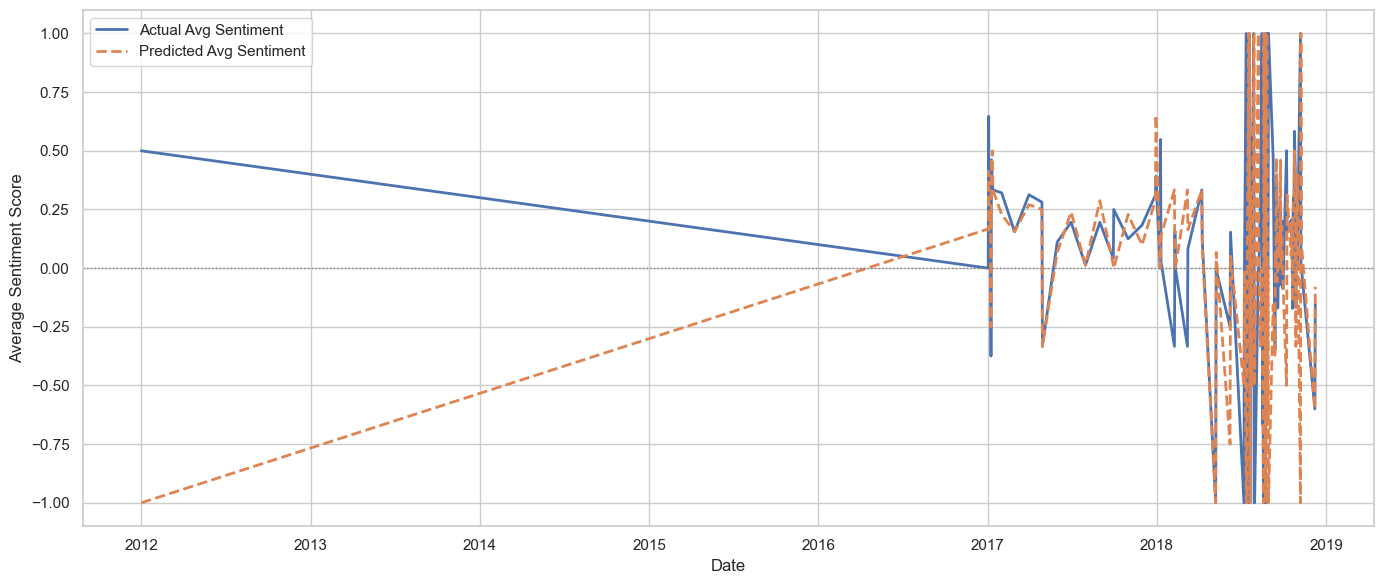

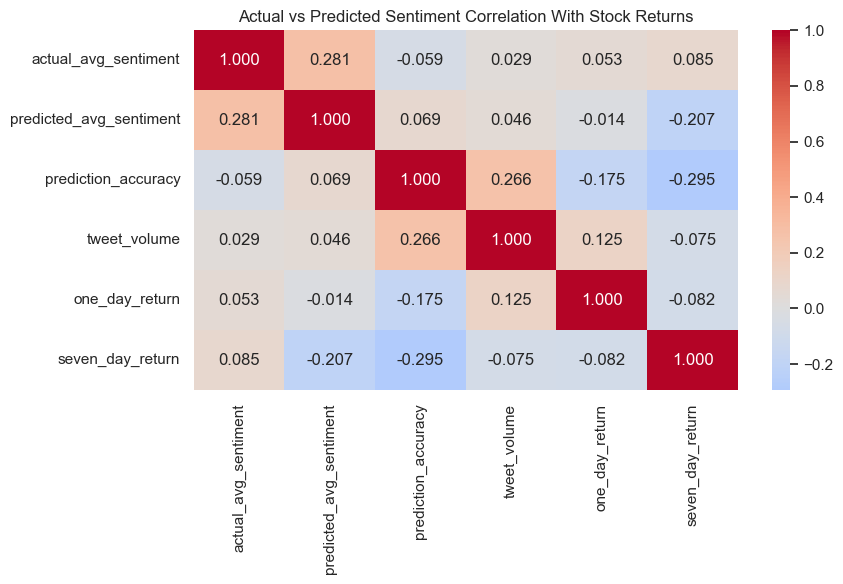

,actual_avg_sentiment,predicted_avg_sentiment,prediction_accuracy,tweet_volume,one_day_return,seven_day_return
actual_avg_sentiment,1.000000,0.281479,-0.059321,0.028776,0.053033,0.084733
predicted_avg_sentiment,0.281479,1.000000,0.069406,0.046283,-0.014012,-0.207197
prediction_accuracy,-0.059321,0.069406,1.000000,0.266368,-0.175007,-0.294960
tweet_volume,0.028776,0.046283,0.266368,1.000000,0.124599,-0.074800
one_day_return,0.053033,-0.014012,-0.175007,0.124599,1.000000,-0.082047
seven_day_return,0.084733,-0.207197,-0.294960,-0.074800,-0.082047,1.000000


In [71]:
if 'best_model_name' not in globals():
    if 'evaluation_df' in globals() and not evaluation_df.empty:
        best_model_name = evaluation_df.iloc[0]['Model']
    else:
        best_model_name = None

if best_model_name is None or best_model_name not in model_predictions:
    print('Predicted sentiment impact analysis skipped. Run model evaluation first so the best model can be selected.')
else:
    if 'model_df' in globals() and 'X_test_text' in globals():
        sentiment_compare_df = model_df.loc[X_test_text.index].copy()
    else:
        sentiment_compare_df = None

    if sentiment_compare_df is None:
        print('Predicted sentiment impact analysis skipped because the test split dataframe is not available.')
    else:
        sentiment_compare_df['actual_label_id'] = np.asarray(model_truths[best_model_name])
        sentiment_compare_df['predicted_label_id'] = np.asarray(model_predictions[best_model_name])
        sentiment_compare_df['actual_sentiment'] = label_encoder.inverse_transform(sentiment_compare_df['actual_label_id'])
        sentiment_compare_df['predicted_sentiment'] = label_encoder.inverse_transform(sentiment_compare_df['predicted_label_id'])
        sentiment_compare_df['prediction_correct'] = sentiment_compare_df['actual_sentiment'] == sentiment_compare_df['predicted_sentiment']

        extra_cols = [col for col in ['DATE', 'STOCK', 'LAST_PRICE', '1_DAY_RETURN', '2_DAY_RETURN', '3_DAY_RETURN', '7_DAY_RETURN', 'PX_VOLUME', 'VOLATILITY_10D', 'VOLATILITY_30D'] if col in df.columns]
        if extra_cols:
            if 'full_model_df' in globals() and 'model_df' in globals():
                source_context_df = df.loc[full_model_df.index, extra_cols].reset_index(drop=True)
                sentiment_compare_df = sentiment_compare_df.join(source_context_df.loc[sentiment_compare_df.index], how='left', rsuffix='_source')
            else:
                sentiment_compare_df = sentiment_compare_df.join(df.loc[sentiment_compare_df.index, extra_cols], how='left', rsuffix='_source')

        if 'DATE' in sentiment_compare_df.columns:
            sentiment_compare_df['DATE'] = pd.to_datetime(sentiment_compare_df['DATE'], errors='coerce')
            sentiment_compare_df['date_only'] = sentiment_compare_df['DATE'].dt.floor('D')

        sentiment_score_map = {'negative': -1, 'neutral': 0, 'positive': 1}
        sentiment_compare_df['actual_sentiment_score'] = sentiment_compare_df['actual_sentiment'].map(sentiment_score_map)
        sentiment_compare_df['predicted_sentiment_score'] = sentiment_compare_df['predicted_sentiment'].map(sentiment_score_map)

        for col in ['LAST_PRICE', '1_DAY_RETURN', '2_DAY_RETURN', '3_DAY_RETURN', '7_DAY_RETURN', 'PX_VOLUME', 'VOLATILITY_10D', 'VOLATILITY_30D']:
            if col in sentiment_compare_df.columns:
                sentiment_compare_df[col] = pd.to_numeric(sentiment_compare_df[col], errors='coerce')

        print(f'Best model used for predicted sentiment: {best_model_name}')
        print(f'Rows used after stock filtering: {len(sentiment_compare_df):,}')
        print(f'Tweet-level sentiment prediction accuracy for selected stock: {sentiment_compare_df["prediction_correct"].mean():.4f}')

        display(sentiment_compare_df[[
            col for col in ['DATE', 'STOCK', 'TWEET', 'actual_sentiment', 'predicted_sentiment', 'prediction_correct', 'LAST_PRICE', '1_DAY_RETURN']
            if col in sentiment_compare_df.columns
        ]].head(10))

        if 'date_only' not in sentiment_compare_df.columns:
            print('Daily actual-vs-predicted impact skipped because DATE is not available.')
        else:
            daily_agg = {
                'actual_avg_sentiment': ('actual_sentiment_score', 'mean'),
                'predicted_avg_sentiment': ('predicted_sentiment_score', 'mean'),
                'prediction_accuracy': ('prediction_correct', 'mean'),
                'tweet_volume': ('predicted_sentiment_score', 'count')
            }
            if 'LAST_PRICE' in sentiment_compare_df.columns:
                daily_agg['last_price'] = ('LAST_PRICE', 'last')
            if '1_DAY_RETURN' in sentiment_compare_df.columns:
                daily_agg['one_day_return'] = ('1_DAY_RETURN', 'mean')
            if '7_DAY_RETURN' in sentiment_compare_df.columns:
                daily_agg['seven_day_return'] = ('7_DAY_RETURN', 'mean')

            actual_predicted_daily_df = (
                sentiment_compare_df
                .dropna(subset=['date_only'])
                .groupby('date_only')
                .agg(**daily_agg)
                .reset_index()
                .sort_values('date_only')
            )

            display(actual_predicted_daily_df.head())

            plt.figure(figsize=(14, 6))
            plt.plot(actual_predicted_daily_df['date_only'], actual_predicted_daily_df['actual_avg_sentiment'], label='Actual Avg Sentiment', linewidth=2)
            plt.plot(actual_predicted_daily_df['date_only'], actual_predicted_daily_df['predicted_avg_sentiment'], label='Predicted Avg Sentiment', linewidth=2, linestyle='--')
            plt.axhline(0, color='gray', linestyle=':', linewidth=1)
            plt.xlabel('Date')
            plt.ylabel('Average Sentiment Score')
            plt.legend()
            plt.tight_layout()
            plt.show()

            return_cols_for_corr = [col for col in ['one_day_return', 'seven_day_return'] if col in actual_predicted_daily_df.columns]
            if return_cols_for_corr:
                sentiment_return_corr = actual_predicted_daily_df[[
                    'actual_avg_sentiment',
                    'predicted_avg_sentiment',
                    'prediction_accuracy',
                    'tweet_volume'
                ] + return_cols_for_corr].corr()

                plt.figure(figsize=(9, 6))
                sns.heatmap(sentiment_return_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0)
                plt.title('Actual vs Predicted Sentiment Correlation With Stock Returns')
                plt.tight_layout()
                plt.show()

                display(sentiment_return_corr)


## Stock Impact Interpretation

The correlation heatmap compares actual sentiment, predicted sentiment, prediction accuracy, tweet volume, and stock returns. The results show that actual average sentiment has a very weak positive relationship with one-day return and seven-day return. This shows that more positive tweet sentiment is slightly associated with better stock performance, but the correlation is too small to claim strong predictive power.

Predicted average sentiment has almost no relationship with one-day return and a weak negative relationship with seven-day return. This indicates that the model's predicted sentiment does not strongly explain future stock price movement. Although the model can classify sentiment, the predicted sentiment alone is not sufficient to predict stock returns reliably.

The correlation between actual average sentiment and predicted average sentiment is positive, which means the model predictions generally move in the same direction as the reference sentiment labels. However, the relationship is only moderate, showing that the model still makes classification errors.

Tweet volume has a small positive relationship with one-day return, suggesting that higher tweet activity may be linked with short-term market movement. However, this relationship is also weak. Overall, the analysis shows that tweet sentiment can be useful as a supporting market signal, but it should not be used as a standalone stock price prediction method.

# Conclusion

This project analysed Twitter sentiment related to stocks and examined whether public opinion from tweets has a relationship with stock price movement. The workflow included text preprocessing, sentiment labelling, feature extraction, traditional machine learning, deep learning, transformer-based modelling, model comparison, and stock impact analysis.

Among the tested models, Random Forest achieved the strongest overall performance with the highest accuracy, weighted F1-score, and macro F1-score. This suggests that traditional machine learning with TF-IDF features was highly effective for this dataset. Transformer models such as BERT and RoBERTa also performed competitively, but they did not outperform Random Forest in this experiment.

The actual vs predicted sentiment analysis showed that the selected model was able to capture sentiment patterns reasonably well, although the lower macro F1-score indicates that minority classes such as neutral remained more difficult to classify. This highlights the effect of class imbalance in sentiment classification.

The stock impact analysis found only weak correlations between tweet sentiment and stock returns. Actual sentiment showed a small positive relationship with one-day and seven-day returns, while predicted sentiment had a weak or inconsistent relationship with stock movement. Therefore, tweet sentiment should be treated as a supporting market indicator rather than a standalone stock price prediction tool.

Overall, the project shows that NLP models can be useful for extracting public sentiment from financial tweets, but sentiment alone is not sufficient to accurately predict stock price movement. Future work could improve the analysis by using manually labelled sentiment data, larger transformer models, more balanced classes, company-specific modelling, and additional financial indicators such as trading volume, volatility, earnings news, and market index movement.